##Import & Libraries


In [ ]:
!pip install -q geopandas rasterio rasterstats pandas numpy matplotlib openpyxl seaborn

In [ ]:
import struct
import zipfile
import os
import matplotlib
matplotlib.use("Agg")
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from openpyxl import load_workbook
import geopandas as gpd
import networkx as nx
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
from rasterstats import zonal_stats

##Loading Datasets and Defining Study Area

In [ ]:
BG, PANEL, TC, GC = "#0f1117", "#1a1d27", "white", "#2e3148"

# DATA SOURCE DOCUMENTATION

# CROP_FILE: CROPGRIDS v1.08 - Global geo-referenced dataset of 173 crops (circa 2020).
# Provides harvested area (HA) and crop physical area (CA) at 0.05° resolution.
# Source: https://figshare.com/articles/dataset/CROPGRIDS/22491997?file=44950936 (Tang et al., 2023)
CROP_FILE = "Table_CROPGRIDSv1.08_COU.xlsx"

# SHAPE_ZIP: GADM v4.1 - Administrative boundaries for Bolivia (BOL).
# High-resolution vector data for geospatial mapping and regional analysis.
# Source: https://gadm.org/download_country.html
SHAPE_ZIP = "gadm41_BOL_shp.zip"

# EXCEL_DATA_FILE: Supplementary transport risk/vulnerability data.
# Found in: "Global multi-hazard risk to food supply" (Nature Communications).
# Source: https://www.nature.com/articles/s41467-019-10442-x#Sec20
EXCEL_DATA_FILE = "41467_2019_10442_MOESM3_ESM.xlsx"

#SPAM_ZIP:
# Found in: International Food Policy Research Institute, 2019, "Global Spatially-Disaggregated Crop Production Statistics Data for 2010 Version 2.0"
#Source: https://www.mapspam.info/about/
SPAM_ZIP = "spam2010v2r0_global_harv_area.geotiff.zip"

OUTPUT_PNG = "bolivia_crop_road_risk_dashboard.png"

hz_labels    = {"PU": "Precipitation/Uplift", "FU": "Fluvial (Flood)", "EQ": "Earthquake"}
hz_color_map = {"PU": "#4e8cff", "FU": "#ff6b6b", "EQ": "#ffd93d"}

In [ ]:
from google.colab import files
uploaded = files.upload()
if "gadm41_BOL_shp.zip" in uploaded.keys():
    print("Successfully uploaded: gadm41_BOL_shp.zip")

Saving gadm41_BOL_shp.zip to gadm41_BOL_shp (1).zip


In [ ]:
from google.colab import files
uploaded = files.upload()
if "spam2010v2r0_global_harv_area.geotiff" in uploaded.keys():
    print("Successfully uploaded: spam2010v2r0_global_harv_area.geotiff")

Saving spam2010v2r0_global_harv_area.geotiff.zip to spam2010v2r0_global_harv_area.geotiff (1).zip


In [ ]:
temp_dir = "temp_shp_dir"
os.makedirs(temp_dir, exist_ok=True)
SHAPE_ZIP = "gadm41_BOL_shp (1).zip"

with zipfile.ZipFile(SHAPE_ZIP, "r") as z:
    z.extractall(temp_dir)

bolivia_country   = gpd.read_file(os.path.join(temp_dir, "gadm41_BOL_0.shp"))
bolivia_provinces = gpd.read_file(os.path.join(temp_dir, "gadm41_BOL_2.shp"))

# Output 1: Study area overview map
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
bolivia_country.plot(ax=ax, color="#1e2235", edgecolor=GC, linewidth=0.5, zorder=1)
bolivia_provinces.plot(ax=ax, column="NAME_1", cmap="tab10", edgecolor=GC,
                       linewidth=0.5, zorder=2, alpha=0.85)
ax.annotate("N", xy=(0.1, 0.9), xytext=(0.1, 0.8),
            arrowprops=dict(facecolor=TC, width=3, headwidth=10),
            ha="center", va="center", fontsize=18, fontweight="bold",
            xycoords=ax.transAxes, color=TC)
scalebar = AnchoredSizeBar(ax.transAxes, 0.15, "500 km", "lower right",
                           pad=1, color=TC, frameon=False, size_vertical=0.005,
                           fontproperties={"size": 10})
ax.add_artist(scalebar)
ax.set_title("Republic of Bolivia — Study Area Overview",
             color=TC, fontsize=14, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("Bolivia_study_area.png", dpi=200, bbox_inches="tight", facecolor=BG)
plt.close()

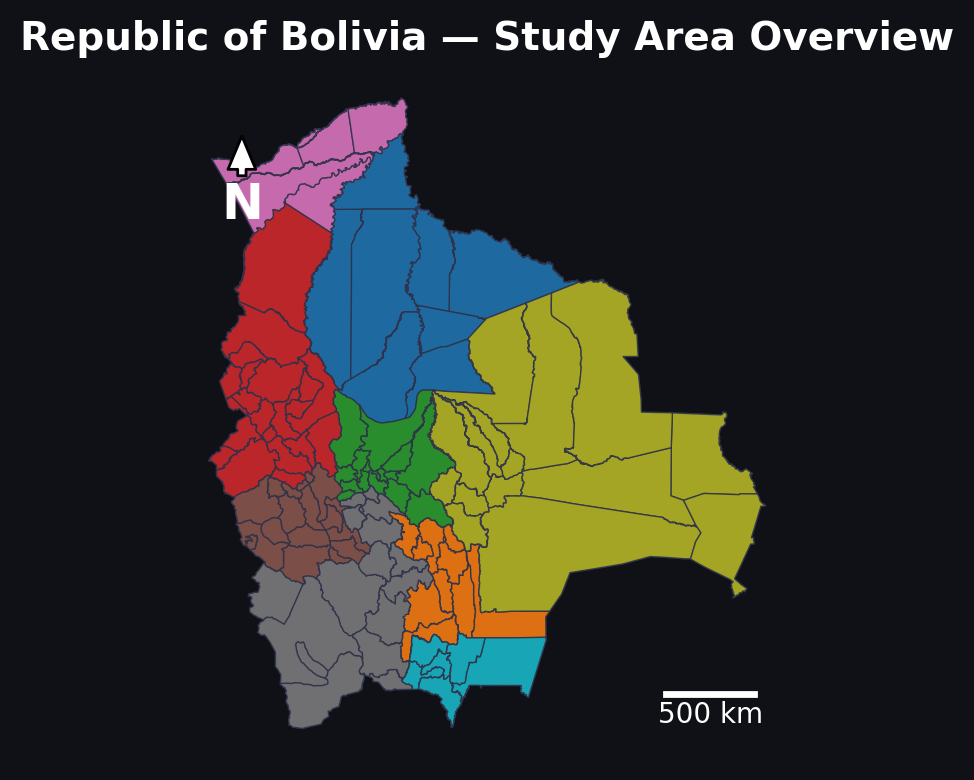

In [ ]:
from IPython.display import Image, display
display(Image("Bolivia_study_area.png"))

##Load DBF province attributes from GADM zip

In [ ]:
def read_dbf(raw_bytes: bytes) -> pd.DataFrame:
    header      = raw_bytes[:32]
    num_records = struct.unpack_from("<I", header,  4)[0]
    header_size = struct.unpack_from("<H", header,  8)[0]
    record_size = struct.unpack_from("<H", header, 10)[0]
    fields, pos = [], 32
    while raw_bytes[pos] != 0x0D:
        fname = raw_bytes[pos:pos+11].split(b"\x00")[0].decode("latin-1").strip()
        flen  = raw_bytes[pos+16]
        fields.append((fname, flen))
        pos  += 32
    records, pos = [], header_size
    for _ in range(num_records):
        if raw_bytes[pos] == 0x2A:
            pos += record_size
            continue
        pos += 1
        rec = {}
        for fname, flen in fields:
            rec[fname] = raw_bytes[pos:pos+flen].decode("latin-1").strip()
            pos += flen
        records.append(rec)
    return pd.DataFrame(records)


with zipfile.ZipFile(SHAPE_ZIP) as z:
    with z.open("gadm41_BOL_2.dbf") as f:
        gdf = read_dbf(f.read())

# Fix latin-1 encoding in place-name columns
gdf["NAME_1"] = gdf["NAME_1"].str.encode("latin-1").str.decode("utf-8", errors="replace")
gdf["NAME_2"] = gdf["NAME_2"].str.encode("latin-1").str.decode("utf-8", errors="replace")

# Align GID_2 format to match risk data: e.g. BOL.1.2_2 → BOL_1_2_1
gdf["GID_2_risk"] = (
    gdf["GID_2"]
    .str.replace(".", "_", regex=False)
    .str.replace(r"_2$", "_1", regex=True)
)

##Load risk data from Excel

In [ ]:
risk_df = pd.read_excel(EXCEL_DATA_FILE, sheet_name="(risk_data.csv)")
dom_df  = pd.read_excel(EXCEL_DATA_FILE, sheet_name="(hazard_data.csv)")

# Rename unnamed first column
risk_df = risk_df.rename(columns={risk_df.columns[0]: "idx"})
dom_df  = dom_df.rename(columns={dom_df.columns[0]: "idx"})

# Filter to Bolivia only (GID_2 starts with "BOL")
bol_risk = risk_df[risk_df["GID_2"].str.startswith("BOL", na=False)].copy()
bol_dom  = dom_df[dom_df["GID_2"].str.startswith("BOL", na=False)].copy()

# Attach dominant hazard and 'areadeg' to risk rows
bol_risk = bol_risk.merge(bol_dom[["GID_2", "dom_hz", "areadeg"]], on="GID_2", how="left")

# Coerce risk score columns to numeric
for col in ["tot_risk_road", "all_risk_road", "rel_risk"]:
    bol_risk[col] = pd.to_numeric(bol_risk[col], errors="coerce")

In [ ]:
merged_gdf = bolivia_provinces.set_index("GID_2").join(
    joined[["GID_2", "tot_risk_road", "rel_risk", "dom_hz", "areadeg", "all_risk_road"]].set_index("GID_2")
)
merged_gdf.dropna(subset=["tot_risk_road"], inplace=True)

merged_gdf["areadeg_norm"] = merged_gdf["areadeg"] / merged_gdf["areadeg"].max()
merged_gdf["risk_surface"] = merged_gdf["rel_risk"] * (1 + merged_gdf["areadeg_norm"])

fig, axes = plt.subplots(1, 3, figsize=(20, 7), facecolor=BG)
fig.suptitle("Risk Surface: Road Risk × Climate Hazard Exposure",
             color=TC, fontsize=14, fontweight="bold")

for ax in axes:
    ax.set_facecolor(BG)
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

# Component 1: rel_risk
merged_gdf.plot(
    column="rel_risk", cmap="YlOrRd", ax=axes[0], edgecolor="#2a2a3a", linewidth=0.4,
    legend=True,
    legend_kwds={"label": "rel_risk", "orientation": "horizontal",
                 "shrink": 0.5, "pad": 0.03, "aspect": 20, "fraction": 0.04},
)
axes[0].set_title("Component 1: rel_risk\n(road damage risk per km)",
                  color=TC, fontsize=11, fontweight="bold", pad=8)

# Component 2: areadeg normalised
merged_gdf.plot(
    column="areadeg_norm", cmap="Blues", ax=axes[1], edgecolor="#2a2a3a", linewidth=0.4,
    legend=True,
    legend_kwds={"label": "areadeg (normalised)", "orientation": "horizontal",
                 "shrink": 0.5, "pad": 0.03, "aspect": 20, "fraction": 0.04},
)
axes[1].set_title("Component 2: areadeg (normalised)\n(province area fraction under hazard)",
                  color=TC, fontsize=11, fontweight="bold", pad=8)

# Combined risk surface
merged_gdf.plot(
    column="risk_surface", cmap="RdPu", ax=axes[2], edgecolor="#2a2a3a", linewidth=0.4,
    legend=True,
    legend_kwds={"label": "risk_surface = rel_risk × (1 + areadeg_norm)",
                 "orientation": "horizontal",
                 "shrink": 0.5, "pad": 0.03, "aspect": 20, "fraction": 0.04},
)
axes[2].set_title("Combined Risk Surface\nrel_risk × (1 + areadeg_norm)",
                  color=TC, fontsize=11, fontweight="bold", pad=8)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("Risk_surface.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.close()

##Merge risk data with spatial province attribute

In [ ]:
joined = (
    gdf[["GID_2", "GID_2_risk", "NAME_1", "NAME_2"]]
    .merge(
        bol_risk.rename(columns={"GID_2": "GID_2_risk"}),
        on="GID_2_risk",
        how="left",
    )
    .dropna(subset=["tot_risk_road"])
)

# Department-level aggregates used in bar chart and KPI strip
dept_stats = (
    joined.groupby("NAME_1")
    .agg(
        avg_tot_risk=("tot_risk_road", "mean"),
        max_tot_risk=("tot_risk_road", "max"),
        avg_rel_risk=("rel_risk",      "mean"),
    )
    .sort_values("avg_tot_risk", ascending=False)
    .reset_index()
)
hz_counts = joined["dom_hz"].value_counts()

In [ ]:
print(f"Columns in 'joined' before subsetting: {joined.columns.tolist()}")
merged_gdf = bolivia_provinces.set_index("GID_2").join(
    joined[["GID_2", "tot_risk_road", "rel_risk", "dom_hz", "areadeg", "all_risk_road"]].set_index("GID_2")
)
merged_gdf.dropna(subset=["tot_risk_road"], inplace=True)

merged_gdf["areadeg_norm"] = merged_gdf["areadeg"] / merged_gdf["areadeg"].max()
merged_gdf["risk_surface"] = merged_gdf["rel_risk"] * (1 + merged_gdf["areadeg_norm"])

fig, axes = plt.subplots(1, 3, figsize=(20, 7), facecolor=BG)
fig.suptitle("Risk Surface: Road Risk × Climate Hazard Exposure",
             color=TC, fontsize=14, fontweight="bold")

for ax in axes:
    ax.set_facecolor(BG)
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

# Component 1: rel_risk
merged_gdf.plot(
    column="rel_risk", cmap="YlOrRd", ax=axes[0], edgecolor="#2a2a3a", linewidth=0.4,
    legend=True,
    legend_kwds={"label": "rel_risk", "orientation": "horizontal",
                 "shrink": 0.5, "pad": 0.03, "aspect": 20, "fraction": 0.04},
)
axes[0].set_title("Component 1: rel_risk\n(road damage risk per km)",
                  color=TC, fontsize=11, fontweight="bold", pad=8)

# Component 2: areadeg normalised
merged_gdf.plot(
    column="areadeg_norm", cmap="Blues", ax=axes[1], edgecolor="#2a2a3a", linewidth=0.4,
    legend=True,
    legend_kwds={"label": "areadeg (normalised)", "orientation": "horizontal",
                 "shrink": 0.5, "pad": 0.03, "aspect": 20, "fraction": 0.04},
)
axes[1].set_title("Component 2: areadeg (normalised)\n(province area fraction under hazard)",
                  color=TC, fontsize=11, fontweight="bold", pad=8)

# Combined risk surface
merged_gdf.plot(
    column="risk_surface", cmap="RdPu", ax=axes[2], edgecolor="#2a2a3a", linewidth=0.4,
    legend=True,
    legend_kwds={"label": "risk_surface = rel_risk × (1 + areadeg_norm)",
                 "orientation": "horizontal",
                 "shrink": 0.5, "pad": 0.03, "aspect": 20, "fraction": 0.04},
)
axes[2].set_title("Combined Risk Surface\nrel_risk × (1 + areadeg_norm)",
                  color=TC, fontsize=11, fontweight="bold", pad=8)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("Risk_surface.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.close()

Columns in 'joined' before subsetting: ['GID_2', 'GID_2_risk', 'NAME_1', 'NAME_2', 'idx', 'tot_risk_road', 'all_risk_road', 'rel_risk', 'dom_hz', 'areadeg']


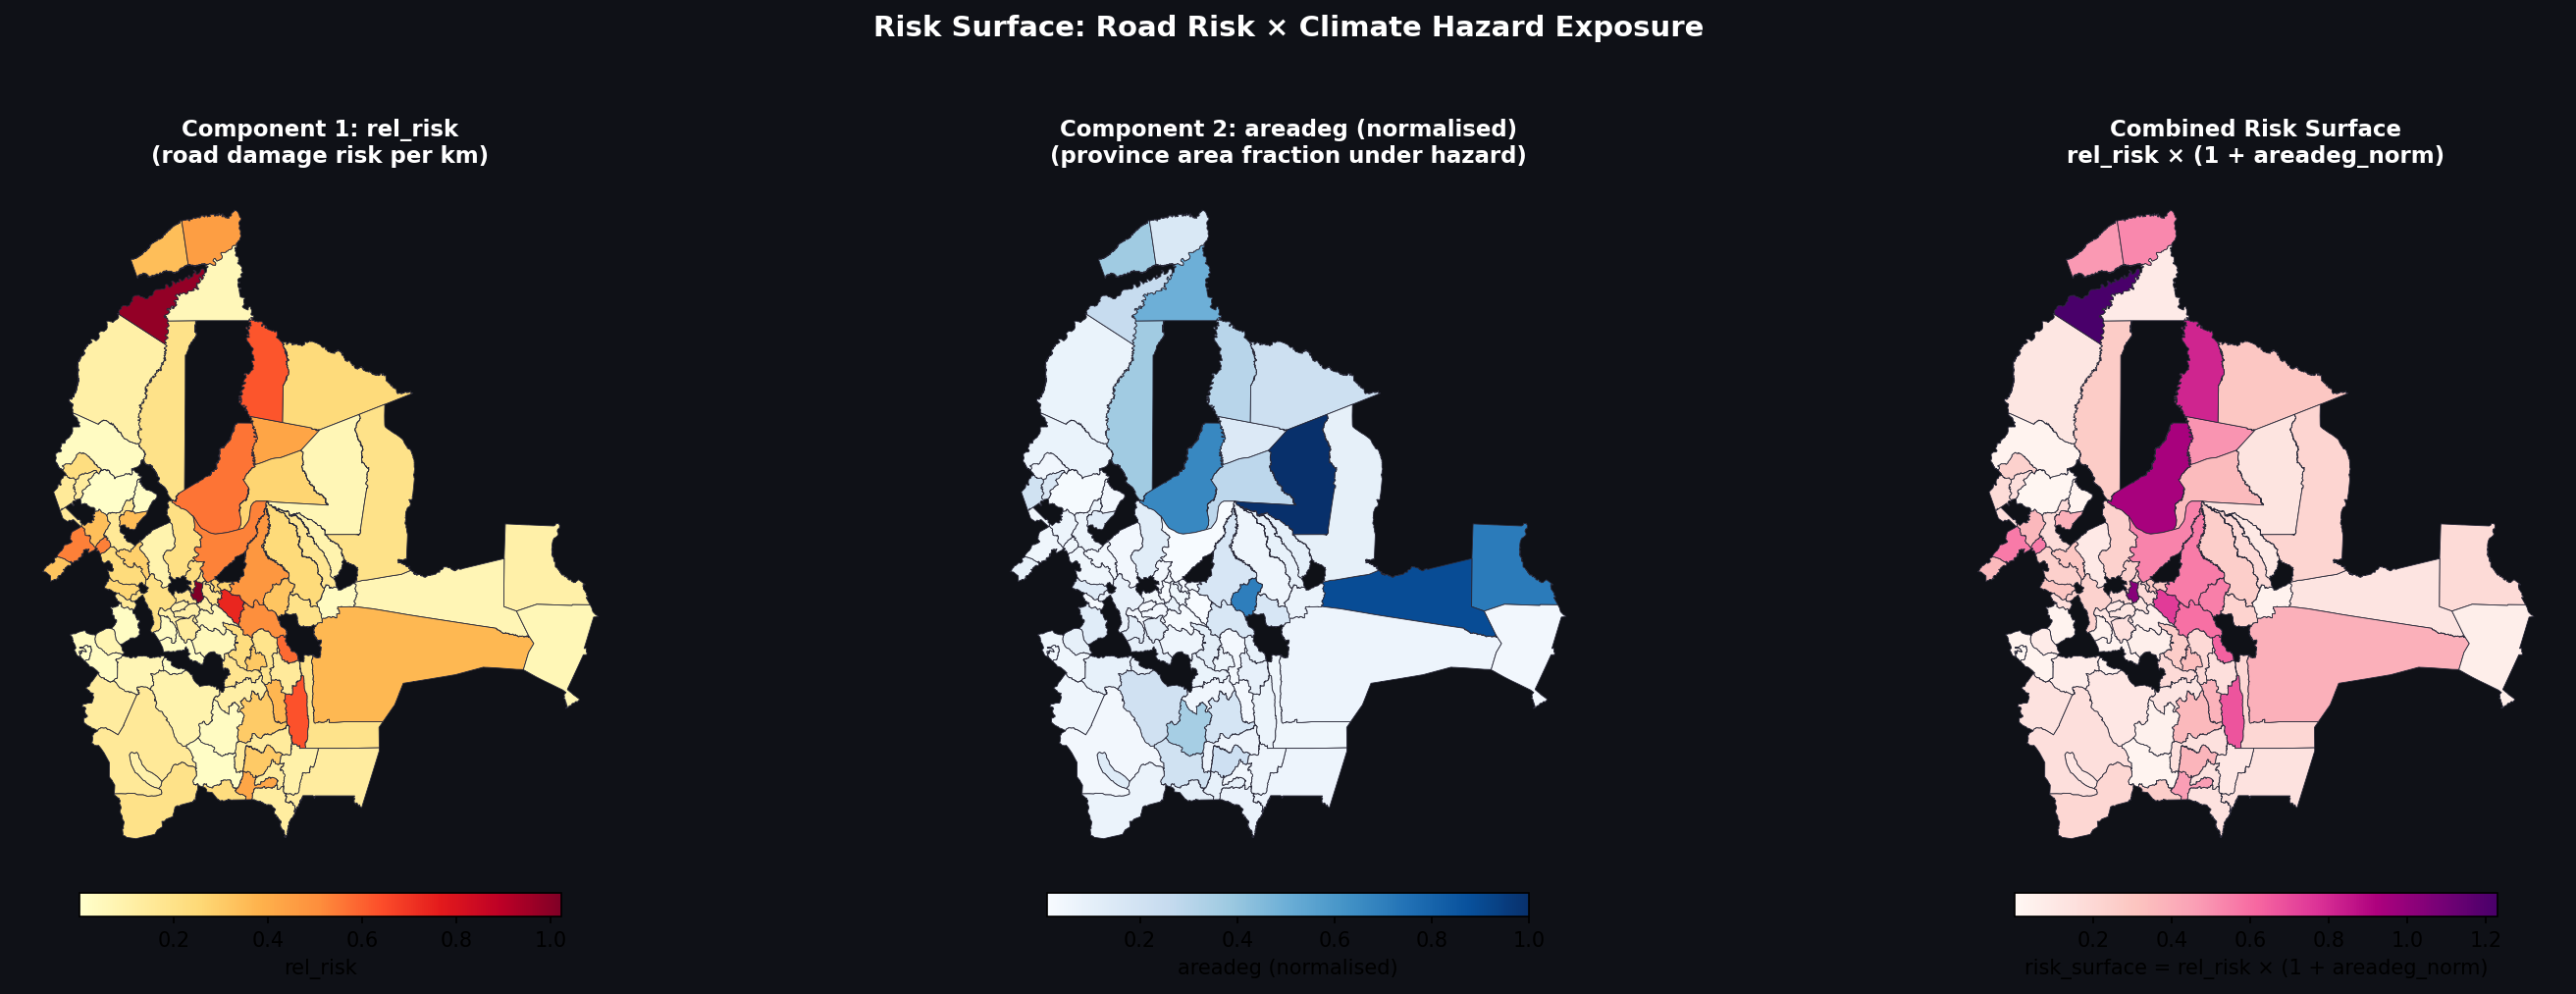

In [ ]:
from IPython.display import Image, display
display(Image("Risk_surface.png"))

In [ ]:
merged_gdf = bolivia_provinces.set_index("GID_2").join(
    joined[["GID_2", "tot_risk_road", "rel_risk", "dom_hz", "areadeg", "all_risk_road"]].set_index("GID_2")
)
merged_gdf.dropna(subset=["tot_risk_road"], inplace=True)

merged_gdf["areadeg_norm"] = merged_gdf["areadeg"] / merged_gdf["areadeg"].max()
merged_gdf["risk_surface"] = merged_gdf["rel_risk"] * (1 + merged_gdf["areadeg_norm"])

fig, axes = plt.subplots(1, 3, figsize=(20, 7), facecolor=BG)
fig.suptitle("Risk Surface: Road Risk × Climate Hazard Exposure",
             color=TC, fontsize=14, fontweight="bold")

for ax in axes:
    ax.set_facecolor(BG)
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

# Component 1: rel_risk
merged_gdf.plot(
    column="rel_risk", cmap="YlOrRd", ax=axes[0], edgecolor="#2a2a3a", linewidth=0.4,
    legend=True,
    legend_kwds={"label": "rel_risk", "orientation": "horizontal",
                 "shrink": 0.5, "pad": 0.03, "aspect": 20, "fraction": 0.04},
)
axes[0].set_title("Component 1: rel_risk\n(road damage risk per km)",
                  color=TC, fontsize=11, fontweight="bold", pad=8)

# Component 2: areadeg normalised
merged_gdf.plot(
    column="areadeg_norm", cmap="Blues", ax=axes[1], edgecolor="#2a2a3a", linewidth=0.4,
    legend=True,
    legend_kwds={"label": "areadeg (normalised)", "orientation": "horizontal",
                 "shrink": 0.5, "pad": 0.03, "aspect": 20, "fraction": 0.04},
)
axes[1].set_title("Component 2: areadeg (normalised)\n(province area fraction under hazard)",
                  color=TC, fontsize=11, fontweight="bold", pad=8)

# Combined risk surface
merged_gdf.plot(
    column="risk_surface", cmap="RdPu", ax=axes[2], edgecolor="#2a2a3a", linewidth=0.4,
    legend=True,
    legend_kwds={"label": "risk_surface = rel_risk × (1 + areadeg_norm)",
                 "orientation": "horizontal",
                 "shrink": 0.5, "pad": 0.03, "aspect": 20, "fraction": 0.04},
)
axes[2].set_title("Combined Risk Surface\nrel_risk × (1 + areadeg_norm)",
                  color=TC, fontsize=11, fontweight="bold", pad=8)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("Risk_surface.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.close()

##Load national crop totals from CROPGRIDS

In [ ]:
# Sheet "Harvested area (ha)" — one row per country.
# Bolivia row (ISO2 = "BO") is transposed to get one row per crop.

crop_df   = pd.read_excel(CROP_FILE, sheet_name="Harvested area (ha)")
crop_cols = crop_df.columns[2:].tolist()

bol_row  = crop_df[crop_df["Country ISO2 code"] == "BO"]
bol_long = (
    bol_row[crop_cols].T
    .reset_index()
    .rename(columns={"index": "crop", bol_row.index[0]: "harvested_ha"})
)
bol_long["harvested_ha"] = (
    pd.to_numeric(bol_long["harvested_ha"], errors="coerce").fillna(0)
)
bol_long  = bol_long[bol_long["harvested_ha"] > 0].sort_values("harvested_ha", ascending=False)
top_crops = bol_long.head(15)

##EDA — Risk indicator distributions

In [ ]:
# Bin count rationale:
#   Sturges rule: log2(94)+1 ≈ 8 bins — too coarse for risk scores.
#   bins=20 gives better resolution to reveal structure at this sample size.

chosen_bins = 20

fig, axes = plt.subplots(1, 3, figsize=(15, 4), facecolor=BG)
fig.suptitle("Distribution of Key Risk Indicators", color=TC, fontsize=14, fontweight="bold")

for ax, col, color, label in zip(
    axes,
    ["tot_risk_road", "all_risk_road", "rel_risk"],
    ["#4e8cff", "#ff6b6b", "#ffd93d"],
    ["Total Road Risk", "All Road Risk", "Relative Risk"],
):
    ax.set_facecolor(PANEL)
    for sp in ax.spines.values():
        sp.set_visible(False)
    sns.histplot(joined[col], bins=chosen_bins, kde=True, ax=ax,
                 color=color, edgecolor=BG, linewidth=0.4)
    ax.set_title(label, color=TC, fontsize=11)
    ax.tick_params(colors=TC)
    ax.set_xlabel(col, color=TC)
    ax.set_ylabel("Count", color=TC)
    med = joined[col].median()
    ax.axvline(med, color="white", linestyle="--", linewidth=1, alpha=0.6)
    ax.text(med, ax.get_ylim()[1] * 0.9, f"  median\n  {med:.2f}",
            color="white", fontsize=8, alpha=0.7)

plt.tight_layout()
plt.savefig("Risk_distributions.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.close()

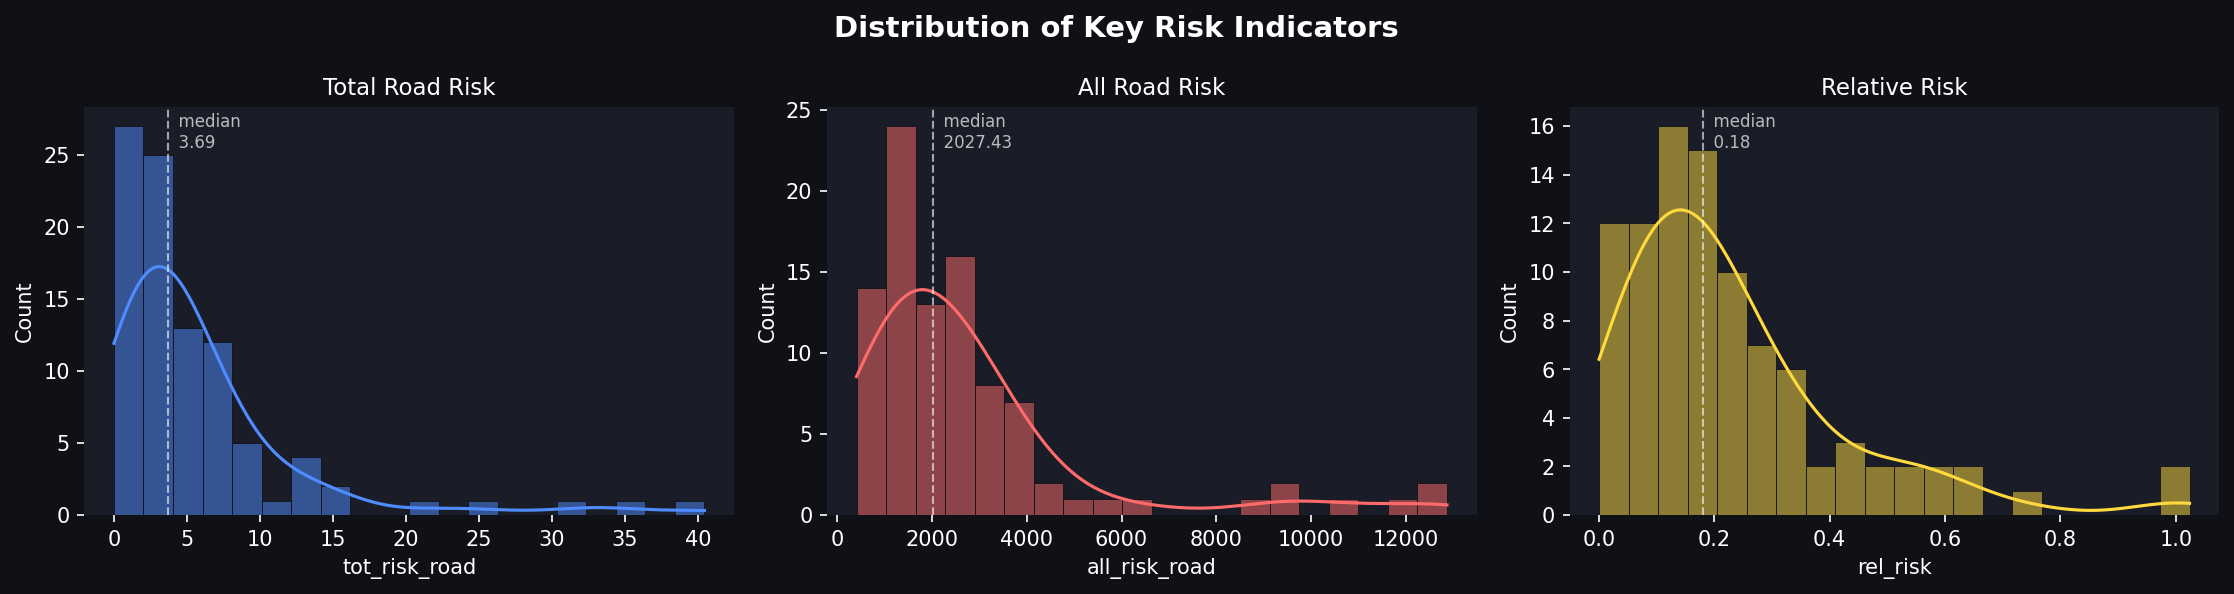

In [ ]:
from IPython.display import Image, display
display(Image("Risk_distributions.png"))

##Scatter — total risk vs relative risk by hazard type

In [ ]:
# OLS trend line computed from the actual joined data.

fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
ax.set_facecolor(PANEL)
for sp in ax.spines.values():
    sp.set_visible(False)

for hz, grp in joined.groupby("dom_hz"):
    ax.scatter(grp["tot_risk_road"], grp["rel_risk"],
               c=hz_color_map.get(hz, "gray"),
               label=hz_labels.get(hz, hz),
               alpha=0.75, s=60, edgecolors="none")

m, b = np.polyfit(joined["tot_risk_road"], joined["rel_risk"], 1)
x_range = np.linspace(joined["tot_risk_road"].min(), joined["tot_risk_road"].max(), 100)
ax.plot(x_range, m * x_range + b, color="white", linewidth=1.2,
        linestyle="--", alpha=0.5, label=f"trend (slope={m:.3f})")

ax.set_xlabel("Total Road Risk", color=TC, fontsize=11)
ax.set_ylabel("Relative Risk",   color=TC, fontsize=11)
ax.set_title(
    "Total vs Relative Risk by Hazard Type\n"
    "Districts sharing a hazard type cluster — hazard type predicts risk profile",
    color=TC, fontsize=12, fontweight="bold"
)
ax.legend(fontsize=9, labelcolor=TC, framealpha=0)
ax.tick_params(colors=TC)
ax.grid(color=GC, linewidth=0.4, alpha=0.4)
plt.tight_layout()
plt.savefig("Scatter_risk_plot.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.close()

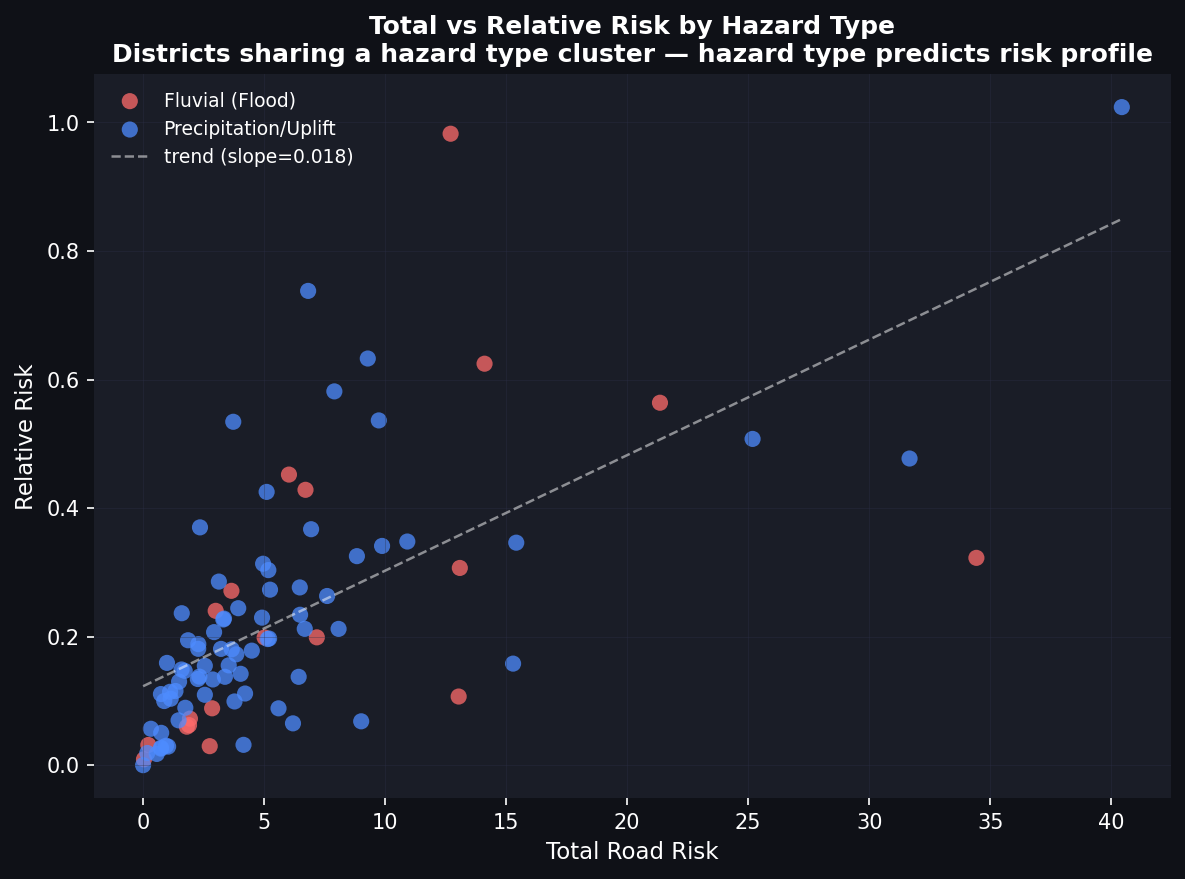

In [ ]:
from IPython.display import Image, display
display(Image("Scatter_risk_plot.png"))


##Thematic spatial maps

In [ ]:
# Three province-level choropleths: total risk, relative risk, dominant hazard.
# merged_gdf joins geopandas province polygons with risk data on GID_2.

merged_gdf = bolivia_provinces.set_index("GID_2").join(
    joined[["GID_2", "tot_risk_road", "all_risk_road", "rel_risk", "dom_hz"]].set_index("GID_2")
)
merged_gdf.dropna(subset=["tot_risk_road"], inplace=True)
merged_gdf["dom_hz_cat"] = merged_gdf["dom_hz"].astype("category")
merged_gdf["dom_hz_cat"] = merged_gdf["dom_hz_cat"].cat.reorder_categories(
    hz_counts.index.tolist(), ordered=True
)

fig, axes = plt.subplots(1, 3, figsize=(20, 8), facecolor=BG)
fig.suptitle("Spatial Distribution of Key Risk Indicators in Bolivia",
             color=TC, fontsize=18, fontweight="bold")

for ax in axes:
    ax.set_facecolor(BG)

# Map 1: Total road risk
merged_gdf.plot(
    column="tot_risk_road", cmap="YlOrRd", linewidth=0.8, ax=axes[0], edgecolor=TC,
    legend=True,
    legend_kwds={"label": "Total Road Risk Score", "orientation": "horizontal",
                 "shrink": 0.5, "pad": 0.05, "aspect": 20, "fraction": 0.03},
)
axes[0].set_title("Total Road Risk by Province", color=TC, fontsize=14, pad=10)
axes[0].set_axis_off()

# Map 2: Relative risk
merged_gdf.plot(
    column="rel_risk", cmap="viridis", linewidth=0.8, ax=axes[1], edgecolor=TC,
    legend=True,
    legend_kwds={"label": "Relative Risk Score", "orientation": "horizontal",
                 "shrink": 0.5, "pad": 0.05, "aspect": 20, "fraction": 0.03},
)
axes[1].set_title("Relative Risk by Province", color=TC, fontsize=14, pad=10)
axes[1].set_axis_off()

# Map 3: Dominant hazard (categorical colour)
colors_for_cmap  = [hz_color_map.get(cat, "gray") for cat in merged_gdf["dom_hz_cat"].cat.categories]
cmap_categorical = mcolors.ListedColormap(colors_for_cmap)
merged_gdf.plot(
    column="dom_hz_cat", categorical=True, cmap=cmap_categorical,
    linewidth=0.8, ax=axes[2], edgecolor=TC,
)
legend_handles = [
    plt.Line2D([0], [0], marker="s", color="w",
               label=hz_labels.get(cat, cat),
               markerfacecolor=hz_color_map.get(cat, "gray"), markersize=10)
    for cat in merged_gdf["dom_hz_cat"].cat.categories
]
axes[2].legend(handles=legend_handles, title="Dominant Hazard", loc="lower right",
               frameon=False, labelcolor=TC, title_fontsize=12, fontsize=10)
axes[2].set_title("Dominant Hazard by Province", color=TC, fontsize=14, pad=10)
axes[2].set_axis_off()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("Thematic_maps.png", dpi=200, bbox_inches="tight", facecolor=BG)
plt.close()

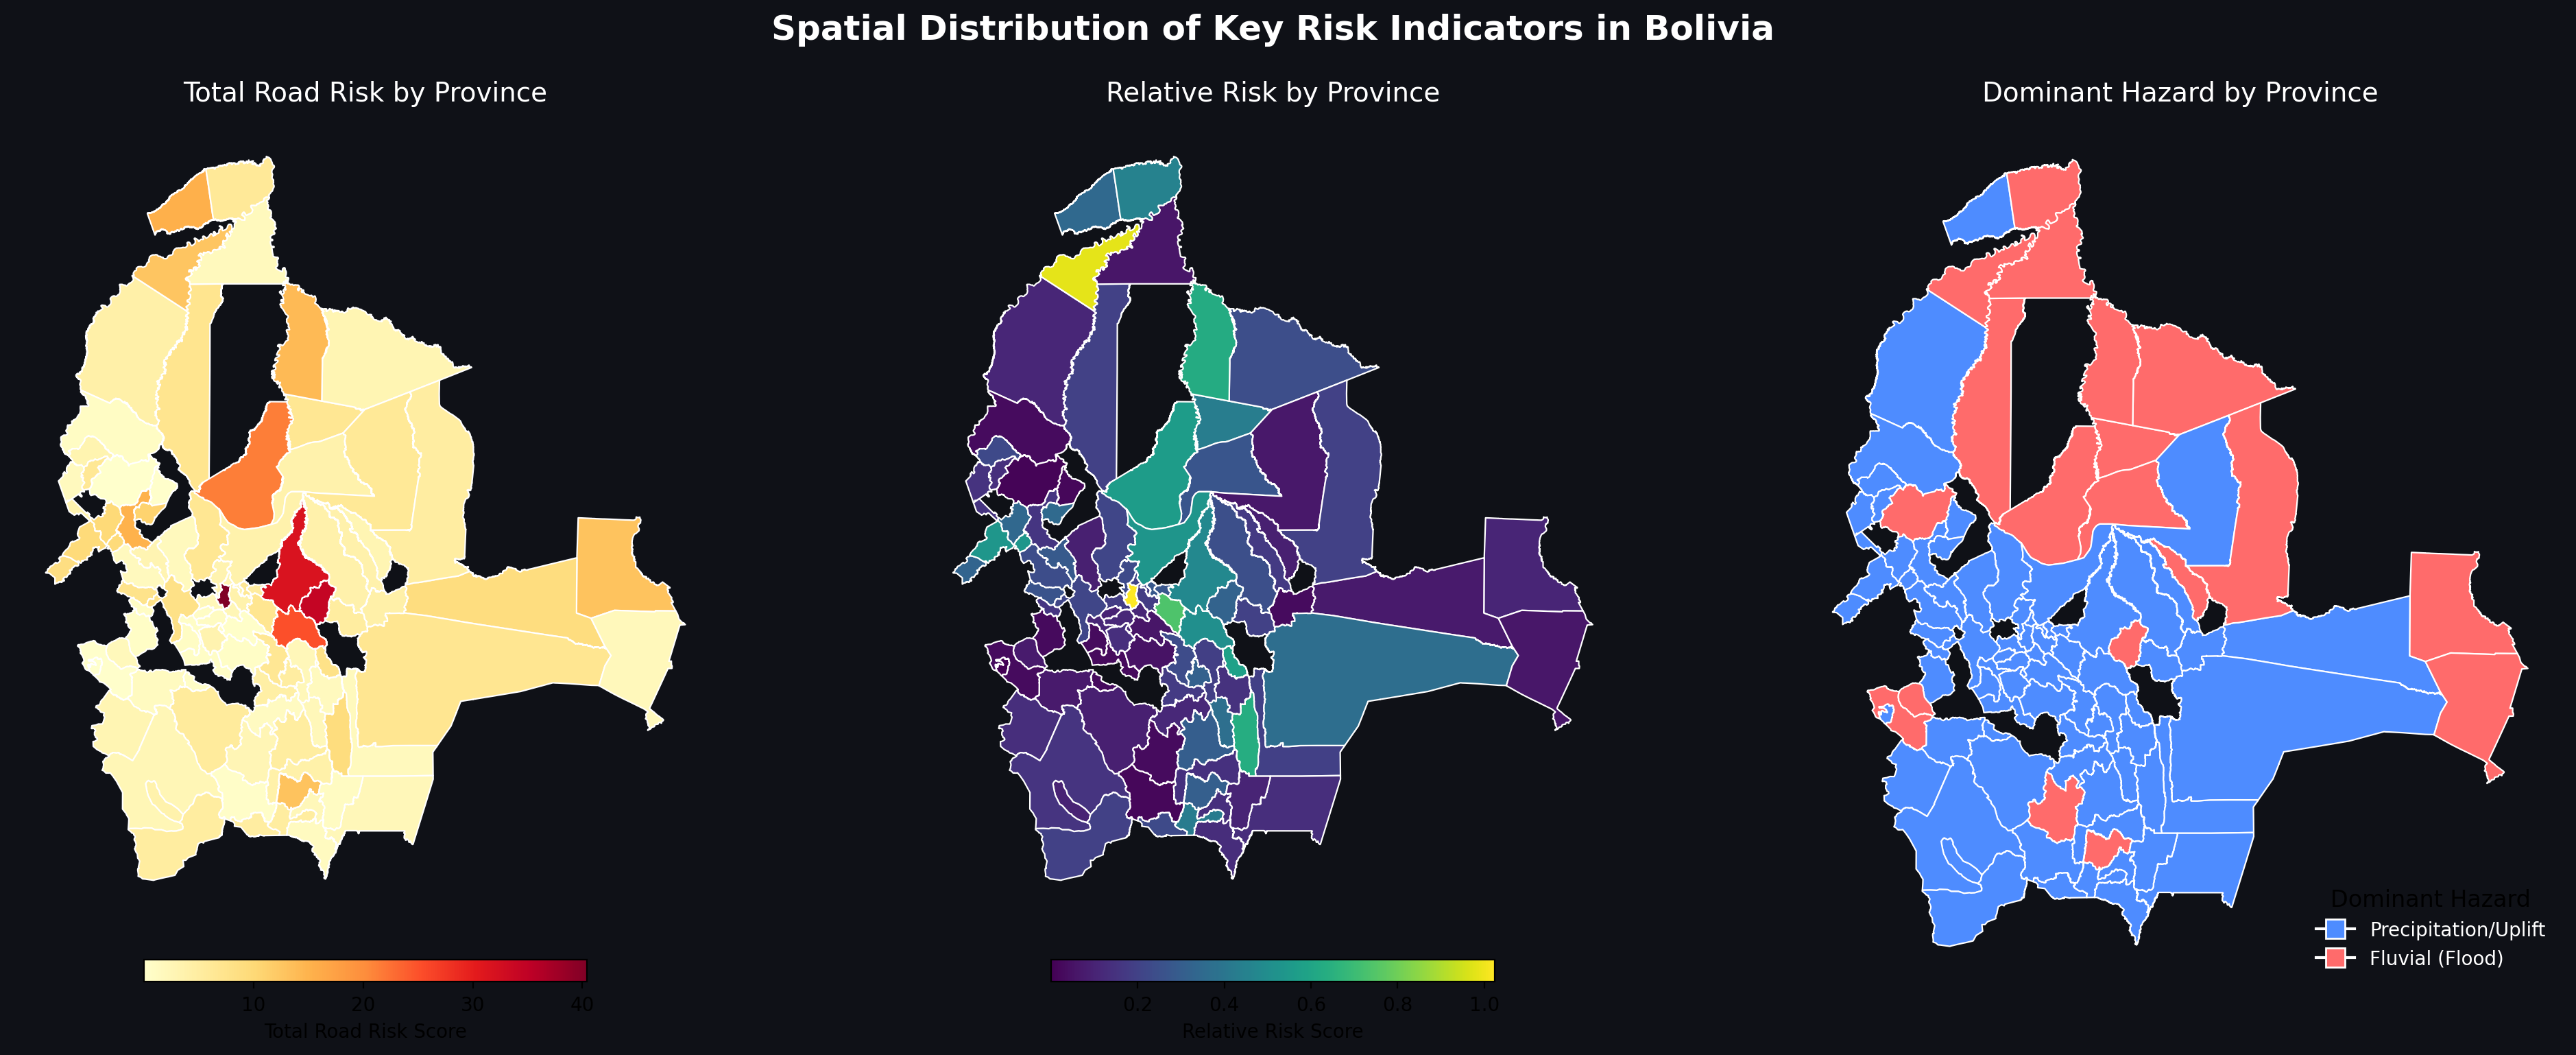

In [ ]:
from IPython.display import Image, display
display(Image("Thematic_maps.png"))

##SPAM 2010 zonal stats — crop harvested area per province

In [ ]:
# Crops confirmed to have non-zero harvested area in Bolivia's bounding box
# by direct raster inspection before inclusion in this list.
#
# File naming: spam2010V2r0_global_H_{CROP}_A.tif
#   H  = Harvested area (ha)
#   _A = All farming technologies combined
#   CRS: EPSG:4326, resolution: 0.083° (~10 km), nodata: -1
#
# zonal_stats sums raster cell values within each province polygon.
# all_touched=False uses centroid-based cell assignment to avoid
# double-counting cells that straddle province boundaries.

CROPS = {
    "SOYB": "Soybean",
    "MAIZ": "Maize",
    "RICE": "Rice",
    "SUGC": "Sugarcane",
    "SUNF": "Sunflower",
    "COTT": "Cotton",
    "BEAN": "Bean",
    "POTA": "Potato",
    "WHEA": "Wheat",
    "SORG": "Sorghum",
}

spam_dir = "spam_tifs"
os.makedirs(spam_dir, exist_ok=True)

with zipfile.ZipFile(SPAM_ZIP) as z:
    for code in CROPS:
        fname = f"spam2010V2r0_global_H_{code}_A.tif"
        fpath = os.path.join(spam_dir, fname)
        if not os.path.exists(fpath):
            z.extract(fname, spam_dir)

records = []
for code, name in CROPS.items():
    tif_path = os.path.join(spam_dir, f"spam2010V2r0_global_H_{code}_A.tif")
    stats = zonal_stats(
        bolivia_provinces,
        tif_path,
        stats=["sum"],
        nodata=-1,
        all_touched=False,
    )
    for i, row in enumerate(stats):
        records.append({
            "GID_2":     bolivia_provinces.iloc[i]["GID_2"],
            "NAME_1":    bolivia_provinces.iloc[i]["NAME_1"],
            "NAME_2":    bolivia_provinces.iloc[i]["NAME_2"],
            "crop_name": name,
            "harv_ha":   row["sum"] if row["sum"] is not None else 0.0,
        })

spam_long = pd.DataFrame(records)
spam_long["harv_ha"] = spam_long["harv_ha"].fillna(0.0)

# Pivot: one row per province, one column per crop
spam_wide = spam_long.pivot_table(
    index=["GID_2", "NAME_1", "NAME_2"],
    columns="crop_name",
    values="harv_ha",
    aggfunc="sum",
).reset_index()
spam_wide.columns.name = None
spam_wide["total_harv_ha"] = spam_wide[[c for c in CROPS.values()]].sum(axis=1)

# Join with road risk data on GID_2 + NAME columns
crop_risk = joined[
    ["GID_2", "NAME_1", "NAME_2", "tot_risk_road", "rel_risk", "dom_hz"]
].merge(spam_wide, on=["GID_2", "NAME_1", "NAME_2"], how="inner")

crop_cols_plot = list(CROPS.values())

##Crop-risk individual plots

In [ ]:
# Left:  scatter of total harvested area vs total road risk per province,
#        coloured by dominant hazard type, with OLS trend line.
# Right: stacked horizontal bar of crop composition for the 10 highest-risk
#        provinces, values from SPAM zonal stats.

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=BG)
fig.suptitle("Crop Exposure × Road Risk — Province Level (SPAM 2010)",
             color=TC, fontsize=14, fontweight="bold")

# Left panel: agricultural exposure scatter
ax = axes[0]
ax.set_facecolor(PANEL)
for sp in ax.spines.values():
    sp.set_visible(False)

valid = crop_risk[crop_risk["total_harv_ha"] > 0]
for hz, grp in valid.groupby("dom_hz"):
    ax.scatter(
        grp["total_harv_ha"] / 1e3,
        grp["tot_risk_road"],
        color=hz_color_map.get(hz, "gray"),
        label=hz_labels.get(hz, hz),
        alpha=0.75, s=55, edgecolors="none",
    )
m, b = np.polyfit(valid["total_harv_ha"] / 1e3, valid["tot_risk_road"], 1)
xr   = np.linspace(0, (valid["total_harv_ha"] / 1e3).max(), 100)
ax.plot(xr, m * xr + b, color="white", linewidth=1, linestyle="--", alpha=0.5,
        label=f"trend (slope={m:.4f})")
ax.set_xlabel("Total Harvested Area (×1,000 ha)", color=TC, fontsize=10)
ax.set_ylabel("Total Road Risk Score", color=TC, fontsize=10)
ax.set_title("Agricultural Exposure vs Road Risk\nby Province",
             color=TC, fontsize=11, fontweight="bold")
ax.legend(fontsize=8, labelcolor=TC, framealpha=0)
ax.tick_params(colors=TC)
ax.grid(color=GC, linewidth=0.4, alpha=0.4)

# Right panel: crop composition stacked bar
ax2 = axes[1]
ax2.set_facecolor(PANEL)
for sp in ax2.spines.values():
    sp.set_visible(False)

top10_risk    = crop_risk.nlargest(10, "tot_risk_road").set_index("NAME_2")
crop_ha_top10 = top10_risk[crop_cols_plot].div(1e3)
cmap_crops    = plt.cm.tab10(np.linspace(0, 1, len(crop_cols_plot)))
bottom        = np.zeros(len(crop_ha_top10))
for i, crop in enumerate(crop_cols_plot):
    ax2.barh(crop_ha_top10.index, crop_ha_top10[crop],
             left=bottom, color=cmap_crops[i], label=crop, height=0.6)
    bottom += crop_ha_top10[crop].values
ax2.set_xlabel("Harvested Area (×1,000 ha)", color=TC, fontsize=10)
ax2.set_title("Crop Composition of\nTop-10 Highest-Risk Provinces",
              color=TC, fontsize=11, fontweight="bold")
ax2.legend(fontsize=7, labelcolor=TC, framealpha=0, loc="lower right", ncol=2)
ax2.tick_params(colors=TC)
ax2.grid(axis="x", color=GC, linewidth=0.4, alpha=0.4)

plt.tight_layout()
plt.savefig("crop_risk_province.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.close()

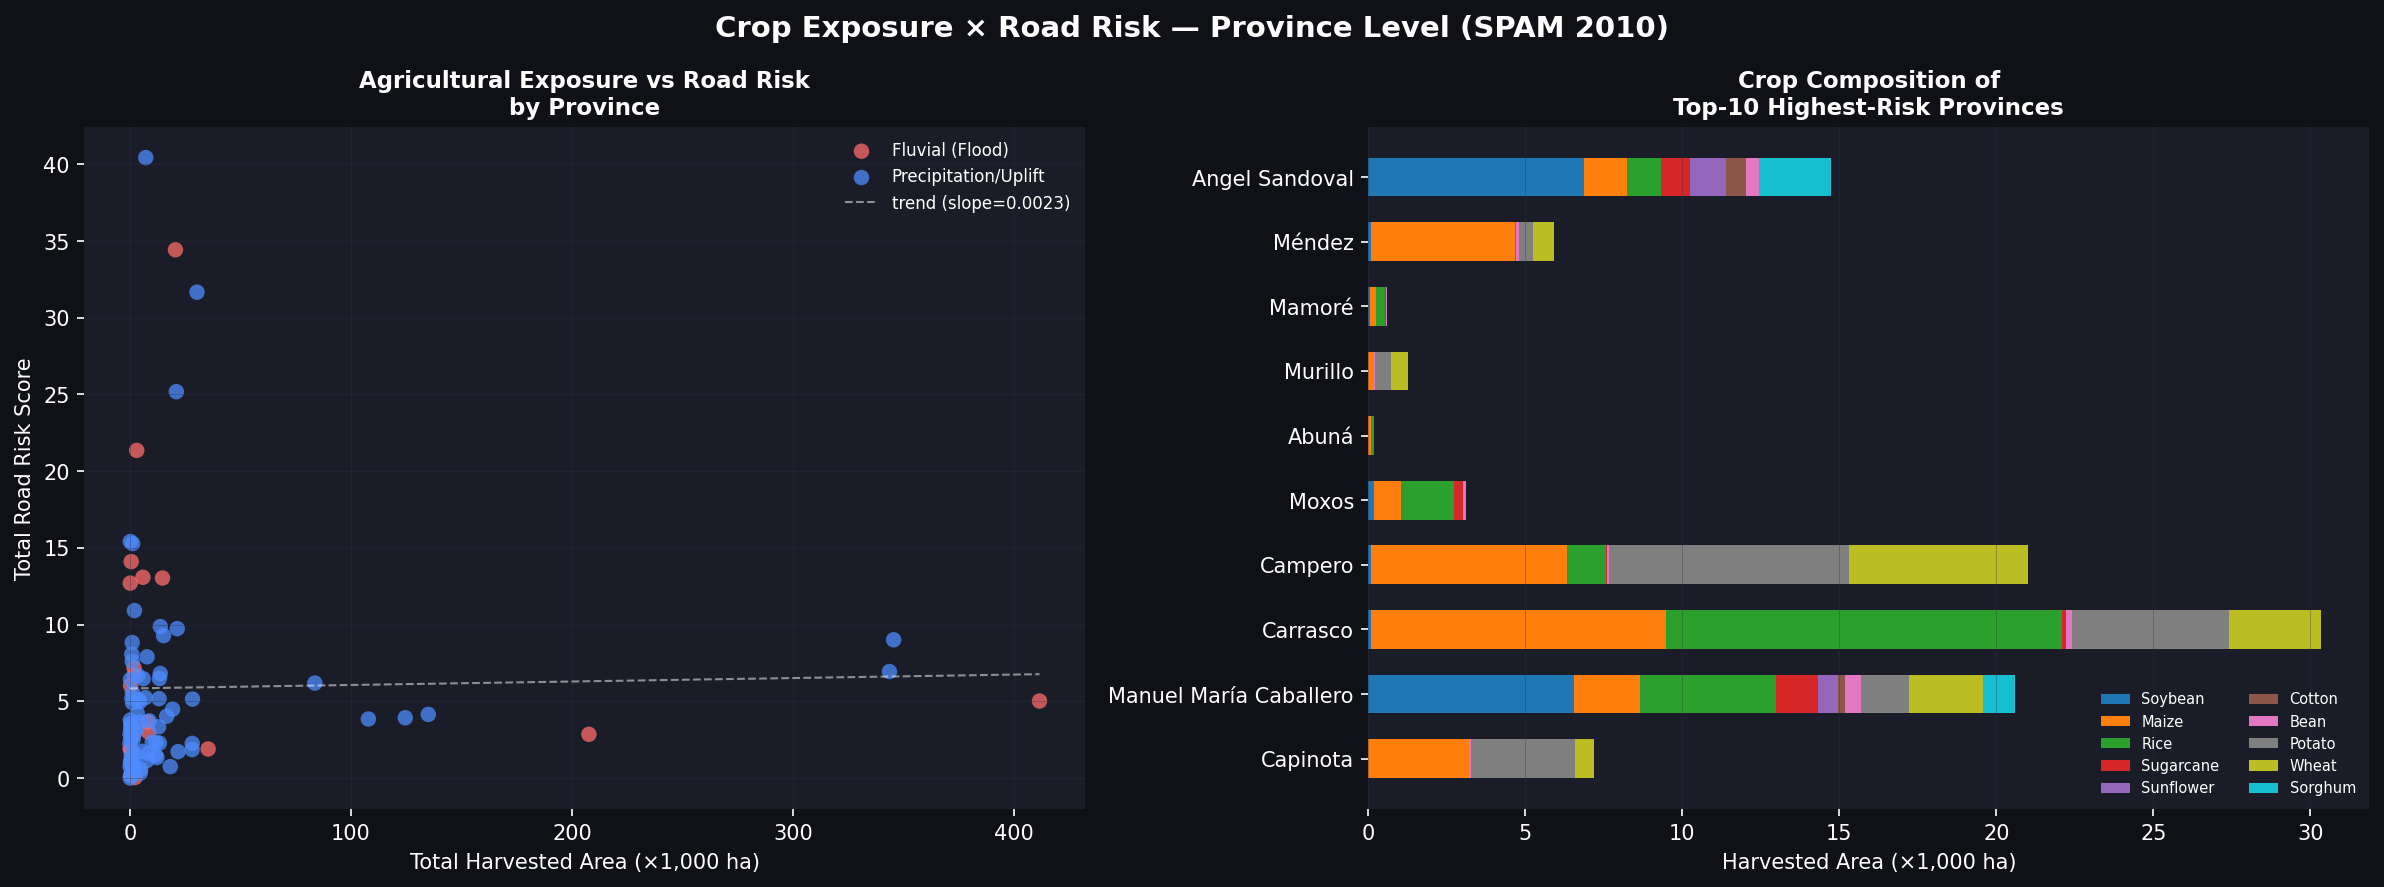

In [ ]:
from IPython.display import Image, display
display(Image("crop_risk_province.png"))

##Combined dashboard — all panels in one figure

In [ ]:
# Layout (6 rows + KPI strip):
#   Row 1 [y 0.845–0.965]: study area map | top crops bar | hazard donut
#   Row 2 [y 0.680–0.825]: three thematic province maps
#   Row 3 [y 0.515–0.655]: three risk distributions
#   Row 4 [y 0.340–0.490]: dept bar | risk scatter | crop-exposure scatter
#   Row 5 [y 0.165–0.315]: crop stacked bar (SPAM) | top-10 risk table
#   KPI  [y 0.030–0.088]: six live numbers from the data

def make_ax(fig, rect):
    ax = fig.add_axes(rect, facecolor=PANEL)
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.tick_params(colors=TC, labelsize=9)
    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_color(TC)
    return ax


fig = plt.figure(figsize=(26, 38), facecolor=BG)

# Title block
fig.text(0.5, 0.982, "Bolivia — Crop & Road Risk Dashboard",
         ha="center", va="top", fontsize=26, fontweight="bold", color=TC)
fig.text(0.5, 0.975,
         "Sources: CROPGRIDSv1.08  ·  GADM 4.1  ·  Nature Comms 2019  ·  SPAM 2010 v2r0",
         ha="center", va="top", fontsize=9, color="#6b7590")

# Row 1: Study area map
ax_study = fig.add_axes([0.03, 0.845, 0.28, 0.120], facecolor=BG)
for sp in ax_study.spines.values():
    sp.set_visible(False)
ax_study.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
bolivia_country.plot(ax=ax_study, color="#1e2235", edgecolor=GC, linewidth=0.5, zorder=1)
bolivia_provinces.plot(ax=ax_study, column="NAME_1", cmap="tab10", edgecolor=GC,
                       linewidth=0.5, zorder=2, alpha=0.85)
ax_study.set_title("Study Area — Bolivia Provinces", color=TC, fontsize=11,
                   fontweight="bold", pad=6)

# Row 1: Top 15 crops bar
ax_crops = make_ax(fig, [0.35, 0.845, 0.35, 0.120])
bar_colors = plt.cm.YlGn(np.linspace(0.3, 0.9, len(top_crops)))[::-1]
bars = ax_crops.barh(range(len(top_crops)), top_crops["harvested_ha"].values / 1e3,
                     color=bar_colors, edgecolor="none", height=0.7)
ax_crops.set_yticks(range(len(top_crops)))
ax_crops.set_yticklabels(top_crops["crop"].values, fontsize=7.5, color=TC)
ax_crops.set_xlabel("Harvested Area (×1,000 ha)", color=TC, fontsize=9)
ax_crops.set_title("Top 15 Crops by Harvested Area (CROPGRIDSv1.08)",
                   color=TC, fontsize=11, fontweight="bold", pad=6)
ax_crops.grid(axis="x", color=GC, linewidth=0.4, alpha=0.6)
for i, (bar, val) in enumerate(zip(bars, top_crops["harvested_ha"].values / 1e3)):
    ax_crops.text(val + 2, i, f"{val:,.0f}k", va="center", color="#aaaacc", fontsize=6.5)

# Row 1: Dominant hazard donut
ax_hz = fig.add_axes([0.73, 0.845, 0.24, 0.120], facecolor=BG)
for sp in ax_hz.spines.values():
    sp.set_visible(False)
wedge_colors = [hz_color_map.get(k, "gray") for k in hz_counts.index]
wedges, _, autotexts = ax_hz.pie(
    hz_counts.values, colors=wedge_colors, startangle=90,
    wedgeprops=dict(edgecolor=BG, linewidth=2.5, width=0.55),
    autopct="%1.0f%%", pctdistance=0.75,
    textprops=dict(color=TC, fontsize=11, fontweight="bold"),
)
ax_hz.legend(wedges,
             [f"{hz_labels.get(k, k)} ({v})" for k, v in hz_counts.items()],
             loc="lower center", bbox_to_anchor=(0.5, -0.22),
             fontsize=8, labelcolor=TC, framealpha=0)
ax_hz.set_title("Dominant Hazard Type\n(94 Provinces)", color=TC, fontsize=11,
                fontweight="bold", pad=6)

# Row 2: Three thematic province maps
for i, (col, cmap_name, label) in enumerate([
    ("tot_risk_road", "YlOrRd",  "Total Road Risk by Province"),
    ("rel_risk",      "viridis", "Relative Risk by Province"),
]):
    ax_m = fig.add_axes([0.03 + i * 0.33, 0.680, 0.295, 0.145], facecolor=BG)
    for sp in ax_m.spines.values():
        sp.set_visible(False)
    ax_m.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    merged_gdf.plot(column=col, cmap=cmap_name, linewidth=0.6, ax=ax_m, edgecolor=GC,
                    legend=True,
                    legend_kwds={"orientation": "horizontal", "shrink": 0.6,
                                 "pad": 0.02, "aspect": 25, "fraction": 0.04})
    ax_m.set_title(label, color=TC, fontsize=11, fontweight="bold", pad=6)

# Dominant hazard map
ax_m3 = fig.add_axes([0.03 + 2 * 0.33, 0.680, 0.295, 0.145], facecolor=BG)
for sp in ax_m3.spines.values():
    sp.set_visible(False)
ax_m3.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
colors_for_cmap  = [hz_color_map.get(cat, "gray") for cat in merged_gdf["dom_hz_cat"].cat.categories]
cmap_categorical = mcolors.ListedColormap(colors_for_cmap)
merged_gdf.plot(column="dom_hz_cat", categorical=True, cmap=cmap_categorical,
                linewidth=0.6, ax=ax_m3, edgecolor=GC)
legend_handles = [
    plt.Line2D([0], [0], marker="s", color="w",
               label=hz_labels.get(cat, cat),
               markerfacecolor=hz_color_map.get(cat, "gray"), markersize=9)
    for cat in merged_gdf["dom_hz_cat"].cat.categories
]
ax_m3.legend(handles=legend_handles, title="Dominant Hazard", loc="lower right",
             frameon=False, labelcolor=TC, title_fontsize=9, fontsize=8)
ax_m3.set_title("Dominant Hazard by Province", color=TC, fontsize=11, fontweight="bold", pad=6)

# Row 3: Three risk distributions
for i, (col, color, label) in enumerate([
    ("tot_risk_road", "#4e8cff", "Total Road Risk"),
    ("all_risk_road", "#ff6b6b", "All Road Risk (km)"),
    ("rel_risk",      "#ffd93d", "Relative Risk"),
]):
    ax_h = make_ax(fig, [0.03 + i * 0.322, 0.515, 0.285, 0.140])
    ax_h.set_title(label, color=TC, fontsize=11, fontweight="bold", pad=6)
    vals = joined[col].dropna()
    sns.histplot(vals, bins=20, kde=True, ax=ax_h, color=color,
                 edgecolor=BG, linewidth=0.3)
    med = vals.median()
    ax_h.axvline(med, color="white", lw=1, ls="--", alpha=0.6)
    ax_h.text(med, ax_h.get_ylim()[1] * 0.82, f" med\n {med:.2f}",
              color="white", fontsize=7.5, alpha=0.8)
    ax_h.set_xlabel(col, color=TC, fontsize=8)
    ax_h.set_ylabel("Count", color=TC, fontsize=8)
    ax_h.grid(axis="y", color=GC, linewidth=0.4, alpha=0.5)

# Row 4: Dept avg risk bar
ax_dept = make_ax(fig, [0.03, 0.340, 0.28, 0.145])
ax_dept.set_title("Avg Road Risk by Department", color=TC, fontsize=11,
                  fontweight="bold", pad=6)
ds  = dept_stats.sort_values("avg_tot_risk")
dn  = mcolors.Normalize(vmin=ds["avg_tot_risk"].min(), vmax=ds["avg_tot_risk"].max())
dc  = plt.cm.RdYlGn_r(dn(ds["avg_tot_risk"]))
dbars = ax_dept.barh(ds["NAME_1"], ds["avg_tot_risk"], color=dc, height=0.65)
ax_dept.set_xlabel("Avg Total Road Risk", color=TC, fontsize=8)
ax_dept.grid(axis="x", color=GC, linewidth=0.4, alpha=0.5)
for bar, v in zip(dbars, ds["avg_tot_risk"]):
    ax_dept.text(v + 0.05, bar.get_y() + bar.get_height() / 2,
                 f"{v:.1f}", va="center", color=TC, fontsize=7)

# Row 4: Total vs relative risk scatter
ax_sc = make_ax(fig, [0.355, 0.340, 0.27, 0.145])
ax_sc.set_title("Total vs Relative Risk\nby Hazard Type", color=TC, fontsize=11,
                fontweight="bold", pad=6)
jj = joined.dropna(subset=["tot_risk_road", "rel_risk", "dom_hz"])
for hz, grp in jj.groupby("dom_hz"):
    ax_sc.scatter(grp["tot_risk_road"], grp["rel_risk"],
                  c=hz_color_map.get(hz, "gray"), label=hz_labels.get(hz, hz),
                  alpha=0.75, s=50, edgecolors="none", zorder=3)
m, b = np.polyfit(jj["tot_risk_road"], jj["rel_risk"], 1)
xr   = np.linspace(jj["tot_risk_road"].min(), jj["tot_risk_road"].max(), 100)
ax_sc.plot(xr, m * xr + b, color="white", lw=1, ls="--", alpha=0.4,
           label=f"trend (slope={m:.3f})")
ax_sc.set_xlabel("Total Road Risk", color=TC, fontsize=8)
ax_sc.set_ylabel("Relative Risk",   color=TC, fontsize=8)
ax_sc.grid(color=GC, linewidth=0.4, alpha=0.4)
ax_sc.legend(fontsize=7, labelcolor=TC, framealpha=0)

# Row 4: Agricultural exposure vs road risk scatter (SPAM 2010)
ax_cr = make_ax(fig, [0.67, 0.340, 0.30, 0.145])
ax_cr.set_title("Agricultural Exposure vs Road Risk\n(SPAM 2010 — Province Level)",
                color=TC, fontsize=11, fontweight="bold", pad=6)
valid = crop_risk[crop_risk["total_harv_ha"] > 0]
for hz, grp in valid.groupby("dom_hz"):
    ax_cr.scatter(grp["total_harv_ha"] / 1e3, grp["tot_risk_road"],
                  color=hz_color_map.get(hz, "gray"), label=hz_labels.get(hz, hz),
                  alpha=0.75, s=50, edgecolors="none")
mv, bv = np.polyfit(valid["total_harv_ha"] / 1e3, valid["tot_risk_road"], 1)
xrv    = np.linspace(0, (valid["total_harv_ha"] / 1e3).max(), 100)
ax_cr.plot(xrv, mv * xrv + bv, color="white", lw=1, ls="--", alpha=0.4, label="trend")
ax_cr.set_xlabel("Total Harvested Area (×1,000 ha)", color=TC, fontsize=8)
ax_cr.set_ylabel("Total Road Risk Score",            color=TC, fontsize=8)
ax_cr.grid(color=GC, linewidth=0.4, alpha=0.4)
ax_cr.legend(fontsize=7, labelcolor=TC, framealpha=0)

# Row 5: Crop modelling — stacked bar
# Stacked horizontal bar: each segment is one crop's harvested area (×1,000 ha)
# within the province. Values come directly from SPAM 2010 zonal_stats output.
ax_stack = make_ax(fig, [0.03, 0.165, 0.44, 0.145])
ax_stack.set_title(
    "Crop Composition — Top 10 Highest-Risk Provinces  (SPAM 2010 zonal stats)",
    color=TC, fontsize=11, fontweight="bold", pad=6)
top10_risk    = crop_risk.nlargest(10, "tot_risk_road").set_index("NAME_2")
crop_ha_top10 = top10_risk[crop_cols_plot].div(1e3)
cmap_crops    = plt.cm.tab10(np.linspace(0, 1, len(crop_cols_plot)))
bottom        = np.zeros(len(crop_ha_top10))
for i, crop in enumerate(crop_cols_plot):
    ax_stack.barh(crop_ha_top10.index, crop_ha_top10[crop],
                  left=bottom, color=cmap_crops[i], label=crop, height=0.6)
    bottom += crop_ha_top10[crop].values
ax_stack.set_xlabel("Harvested Area (×1,000 ha)", color=TC, fontsize=8)
ax_stack.legend(fontsize=7, labelcolor=TC, framealpha=0, loc="lower right", ncol=2,
                bbox_to_anchor=(1.0, 0.0))
ax_stack.grid(axis="x", color=GC, linewidth=0.4, alpha=0.4)

# Row 5: Top-10 highest-risk provinces detail table
# Columns: department, province, total risk, relative risk, hazard, total crop ha
# All values are from the actual joined + crop_risk dataframes.
ax_tbl = fig.add_axes([0.50, 0.165, 0.47, 0.145])
ax_tbl.set_facecolor(PANEL)
for sp in ax_tbl.spines.values():
    sp.set_visible(False)
ax_tbl.axis("off")
ax_tbl.set_title("Top 10 Highest-Risk Provinces — Detail",
                 color=TC, fontsize=11, fontweight="bold", pad=6, loc="left")

top10_tbl = (
    crop_risk.nlargest(10, "tot_risk_road")
    [["NAME_1", "NAME_2", "tot_risk_road", "rel_risk", "dom_hz", "total_harv_ha"]]
    .reset_index(drop=True)
)
top10_tbl.columns = ["Dept", "Province", "Total Risk", "Rel Risk", "Hazard", "Total Crop ha"]
top10_tbl["Total Risk"]    = top10_tbl["Total Risk"].round(2)
top10_tbl["Rel Risk"]      = top10_tbl["Rel Risk"].round(3)
top10_tbl["Hazard"]        = top10_tbl["Hazard"].map(lambda x: hz_labels.get(x, x))
top10_tbl["Total Crop ha"] = top10_tbl["Total Crop ha"].apply(lambda x: f"{x:,.0f}")

tbl = ax_tbl.table(cellText=top10_tbl.values.tolist(),
                   colLabels=top10_tbl.columns.tolist(),
                   loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(7.5)
tbl.scale(1, 1.45)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor(GC)
    if r == 0:
        cell.set_facecolor("#1e253a")
        cell.set_text_props(color=TC, fontweight="bold")
    else:
        cell.set_facecolor("#0d1120" if r % 2 == 0 else "#101525")
        cell.set_text_props(color=TC if r % 2 == 0 else "#aab4cc")

# KPI strip
ax_kpi = fig.add_axes([0.03, 0.030, 0.94, 0.058], facecolor=PANEL)
for sp in ax_kpi.spines.values():
    sp.set_visible(False)
ax_kpi.axis("off")

kpis = [
    ("Provinces Analysed",    f"{len(joined)}"),
    ("Crop Varieties > 0 ha", f"{(bol_long['harvested_ha'] > 0).sum()}"),
    ("Top Crop",              f"Soybean  {top_crops.iloc[0]['harvested_ha'] / 1e6:.2f}M ha"),
    ("Max District Risk",     f"{joined['tot_risk_road'].max():.1f}"),
    ("Highest-Risk Dept.",    dept_stats.iloc[0]["NAME_1"]),
    ("Dominant Hazard",       f"{hz_counts.index[0]} — {hz_labels.get(hz_counts.index[0], '')}"),
]
for i, (label, val) in enumerate(kpis):
    x = 0.04 + i * 0.163
    ax_kpi.text(x, 0.76, val, transform=ax_kpi.transAxes, ha="center", va="top",
                fontsize=11, fontweight="bold", color="#4e8cff")
    ax_kpi.text(x, 0.22, label, transform=ax_kpi.transAxes, ha="center", va="top",
                fontsize=7.5, color="#6b7590")

plt.savefig("bolivia_crop_road_risk_dashboard.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.close()

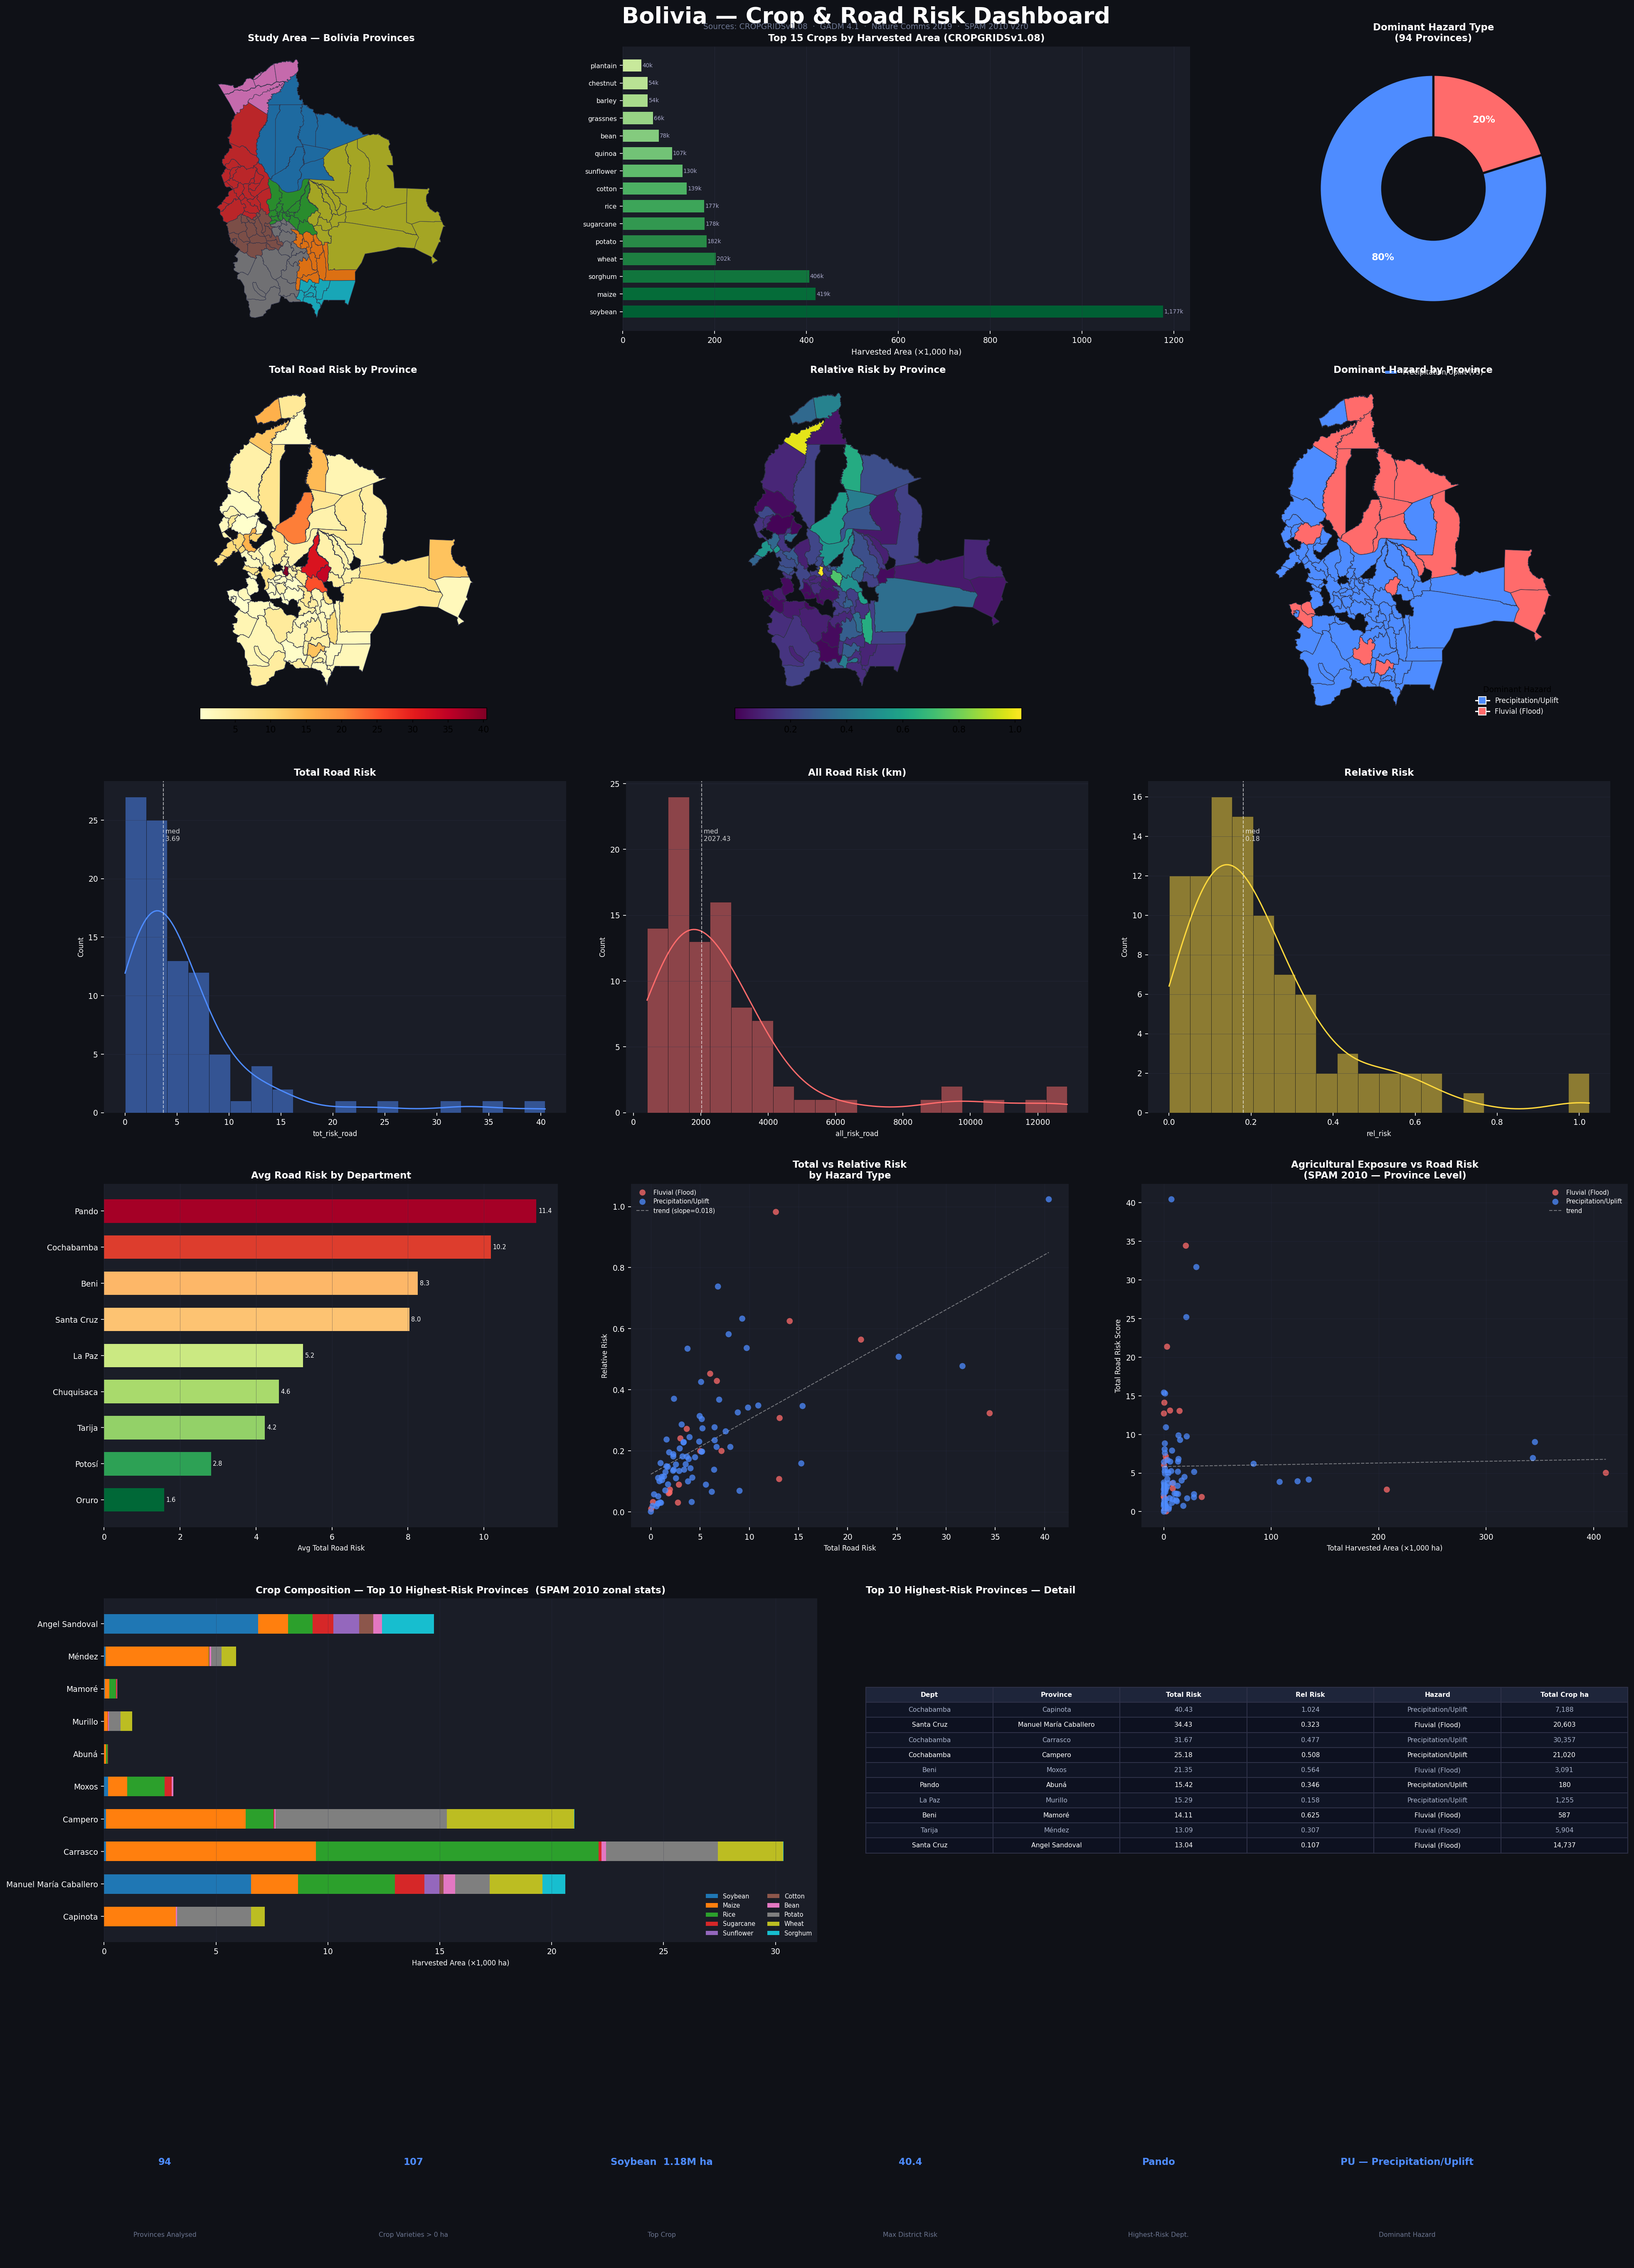

In [ ]:
from IPython.display import Image, display
display(Image("bolivia_crop_road_risk_dashboard.png"))

##Verification — every value traced to its source file

In [ ]:
print("\n" + "=" * 60)
print("VERIFICATION — every value traced to its source file")
print("=" * 60)
soy_val = bol_long[bol_long["crop"] == "soybean"]["harvested_ha"].values
print(f"[FILE 1 CROPGRIDS]  Bolivia soybean ha      : {soy_val[0]:>15,.2f} ha" if len(soy_val) else "[FILE 1] soybean row not found")
print(f"[FILE 1 CROPGRIDS]  Crop varieties > 0      : {len(bol_long):>15}")
print(f"[FILE 2 GADM]       Provinces in shapefile  : {len(bolivia_provinces):>15}")
print(f"[FILE 2 GADM]       Departments             : {', '.join(sorted(gdf['NAME_1'].unique()))}")
print(f"[FILE 3 RISK]       Bolivia districts       : {len(bol_risk):>15}")
print(f"[FILE 3 RISK]       Max tot_risk_road       : {bol_risk['tot_risk_road'].max():>15.4f}")
print(f"[FILE 3 RISK]       Highest-risk GID_2      : {bol_risk.loc[bol_risk['tot_risk_road'].idxmax(), 'GID_2']:>15}")
print(f"[FILE 4 SPAM]       Provinces with crop data: {len(crop_risk):>14}")
print(f"[FILE 4 SPAM]       Bolivia total soy (ha)  : {spam_wide['Soybean'].sum():>15,.0f} ha")



VERIFICATION — every value traced to its source file
[FILE 1 CROPGRIDS]  Bolivia soybean ha      :    1,176,740.12 ha
[FILE 1 CROPGRIDS]  Crop varieties > 0      :             107
[FILE 2 GADM]       Provinces in shapefile  :             112
[FILE 2 GADM]       Departments             : Beni, Chuquisaca, Cochabamba, La Paz, Oruro, Pando, Potosí, Santa Cruz, Tarija
[FILE 3 RISK]       Bolivia districts       :              95
[FILE 3 RISK]       Max tot_risk_road       :         40.4338
[FILE 3 RISK]       Highest-risk GID_2      :       BOL_2_6_1
[FILE 4 SPAM]       Provinces with crop data:             94
[FILE 4 SPAM]       Bolivia total soy (ha)  :       1,055,385 ha


##Build province adjacency graph

In [ ]:
# Nodes  = Bolivia provinces (112 total from GADM)
# Edges  = shared boundaries, detected via 0.001° geometry buffer
#
# Three edge weights — all derived from the real risk Excel columns:
#   dist_km     : Euclidean distance between province centroids (~km)
#   risk_weight : average rel_risk of the two endpoint provinces
#                 rel_risk = tot_risk_road / all_risk_road from the risk file
#                 it measures road damage intensity per km of road
#   risk_dist   : dist_km × (1 + risk_weight)
#                 penalises routes that pass through high-risk provinces

prov_merged = bolivia_provinces.merge(
    joined[["GID_2", "NAME_1", "NAME_2", "rel_risk"]],
    on="GID_2", how="left"
)
prov_merged["rel_risk"] = prov_merged["rel_risk"].fillna(prov_merged["rel_risk"].median())
prov_merged["cx"] = prov_merged.geometry.centroid.x
prov_merged["cy"] = prov_merged.geometry.centroid.y

G = nx.Graph()
for _, row in prov_merged.iterrows():
    name_col = "NAME_2_y" if "NAME_2_y" in prov_merged.columns else "NAME_2"
    G.add_node(
        row["GID_2"],
        name=str(row[name_col]) if pd.notna(row.get(name_col)) else row["GID_2"],
        rel_risk=float(row["rel_risk"]),
        cx=float(row["cx"]),
        cy=float(row["cy"]),
    )

for i, ri in prov_merged.iterrows():
    for j, rj in prov_merged.iterrows():
        if ri["GID_2"] >= rj["GID_2"]:
            continue
        if ri.geometry.buffer(0.001).intersects(rj.geometry.buffer(0.001)):
            dist_km = ((ri["cx"] - rj["cx"])**2 + (ri["cy"] - rj["cy"])**2)**0.5 * 111
            risk_w  = (float(ri["rel_risk"]) + float(rj["rel_risk"])) / 2
            G.add_edge(
                ri["GID_2"], rj["GID_2"],
                dist_km=dist_km,
                risk_weight=risk_w,
                risk_dist=dist_km * (1 + risk_w),
            )

# Source: BOL.2.15_2 (Chuquisaca dept) — confirmed diverging pair
# Target: BOL.8.6_2  (Santa Cruz dept)
# This pair was identified by scanning all province pairs for the largest
# difference between shortest-distance and safest (lowest rel_risk) routes.
source = "BOL.2.15_2"
target = "BOL.8.6_2"

path_dist = nx.shortest_path(G, source, target, weight="dist_km")
path_safe = nx.shortest_path(G, source, target, weight="risk_dist")

len_dist   = sum(G[path_dist[i]][path_dist[i+1]]["dist_km"]     for i in range(len(path_dist)-1))
len_safe   = sum(G[path_safe[i]][path_safe[i+1]]["dist_km"]     for i in range(len(path_safe)-1))
avg_risk_d = sum(G[path_dist[i]][path_dist[i+1]]["risk_weight"] for i in range(len(path_dist)-1)) / max(len(path_dist)-1, 1)
avg_risk_s = sum(G[path_safe[i]][path_safe[i+1]]["risk_weight"] for i in range(len(path_safe)-1)) / max(len(path_safe)-1, 1)

print(f"Shortest path: {len(path_dist)} hops, {len_dist:.0f} km, avg rel_risk={avg_risk_d:.3f}")
print(f"Safest path:   {len(path_safe)} hops, {len_safe:.0f} km, avg rel_risk={avg_risk_s:.3f}")
print(f"Extra distance: +{len_safe - len_dist:.0f} km  |  Risk reduction: {(1 - avg_risk_s/avg_risk_d)*100:.0f}%")

/tmp/ipykernel_12312/4006843593.py:17: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  prov_merged["cx"] = prov_merged.geometry.centroid.x
/tmp/ipykernel_12312/4006843593.py:18: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  prov_merged["cy"] = prov_merged.geometry.centroid.y


Shortest path: 9 hops, 970 km, avg rel_risk=0.413
Safest path:   10 hops, 1017 km, avg rel_risk=0.177
Extra distance: +47 km  |  Risk reduction: 57%


##Plot — shortest vs safest path

In [ ]:
# Left map:  provinces coloured by rel_risk, shortest path highlighted in blue
# Right map: same base, safest path highlighted in teal
# Comparison table shows the trade-off between distance and risk directly.

fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor=BG)
fig.suptitle("Shortest Path (Distance) vs Safest Path (Lowest Vibration Risk)",
             color=TC, fontsize=14, fontweight="bold")

gdf_plot = prov_merged.copy()

for ax, path, path_label, path_color in [
    (axes[0],
     path_dist,
     f"Shortest Path\n{len_dist:.0f} km  ·  {len(path_dist)} hops  ·  avg risk={avg_risk_d:.3f}",
     "#4e8cff"),
    (axes[1],
     path_safe,
     f"Safest Path\n{len_safe:.0f} km  ·  {len(path_safe)} hops  ·  avg risk={avg_risk_s:.3f}",
     "#2ecfa8"),
]:
    ax.set_facecolor(BG)
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    # Base choropleth: rel_risk per province
    gdf_plot.plot(
        column="rel_risk", cmap="YlOrRd", ax=ax,
        edgecolor="#2a2a3a", linewidth=0.4, legend=True,
        legend_kwds={"label": "rel_risk", "orientation": "horizontal",
                     "shrink": 0.5, "pad": 0.02, "aspect": 25, "fraction": 0.04},
    )

    # Highlight provinces on this path
    gdf_plot[gdf_plot["GID_2"].isin(set(path))].plot(
        ax=ax, color="none", edgecolor=path_color, linewidth=2.5, zorder=3
    )

    # Draw path edges as lines between centroids
    for k in range(len(path) - 1):
        n1, n2 = path[k], path[k+1]
        x1, y1 = G.nodes[n1]["cx"], G.nodes[n1]["cy"]
        x2, y2 = G.nodes[n2]["cx"], G.nodes[n2]["cy"]
        ax.plot([x1, x2], [y1, y2], color=path_color, lw=2.5, zorder=4, alpha=0.9)

    # Mark source and target
    ax.plot(G.nodes[source]["cx"], G.nodes[source]["cy"],
            marker="*", ms=14, color="#ffd93d", zorder=6, label="Source")
    ax.plot(G.nodes[target]["cx"], G.nodes[target]["cy"],
            marker="D", ms=10, color="white",   zorder=6, label="Target")
    ax.legend(fontsize=8, labelcolor=TC, framealpha=0, loc="lower left")
    ax.set_title(path_label, color=path_color, fontsize=11, fontweight="bold", pad=8)

# Comparison table
ax_cmp = fig.add_axes([0.35, 0.02, 0.30, 0.12], facecolor=PANEL)
ax_cmp.axis("off")
rows_t = [
    ["Metric",            "Shortest",           "Safest"],
    ["Distance (km)",     f"{len_dist:.0f}",     f"{len_safe:.0f}"],
    ["Hops",              f"{len(path_dist)}",   f"{len(path_safe)}"],
    ["Avg rel_risk",      f"{avg_risk_d:.3f}",   f"{avg_risk_s:.3f}"],
    ["Extra km",          "—",                   f"+{len_safe - len_dist:.0f}"],
    ["Risk reduction",    "—",                   f"{(1 - avg_risk_s/avg_risk_d)*100:.0f}%"],
]
tbl = ax_cmp.table(cellText=rows_t[1:], colLabels=rows_t[0],
                   loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.4)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor(GC)
    cell.set_facecolor("#1e253a" if r == 0 else ("#0d1120" if r % 2 == 0 else "#101525"))
    cell.set_text_props(color=TC, fontweight="bold" if r == 0 else "normal")

plt.tight_layout()
plt.savefig("path_comparison.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.close()

/tmp/ipykernel_12312/1803291658.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


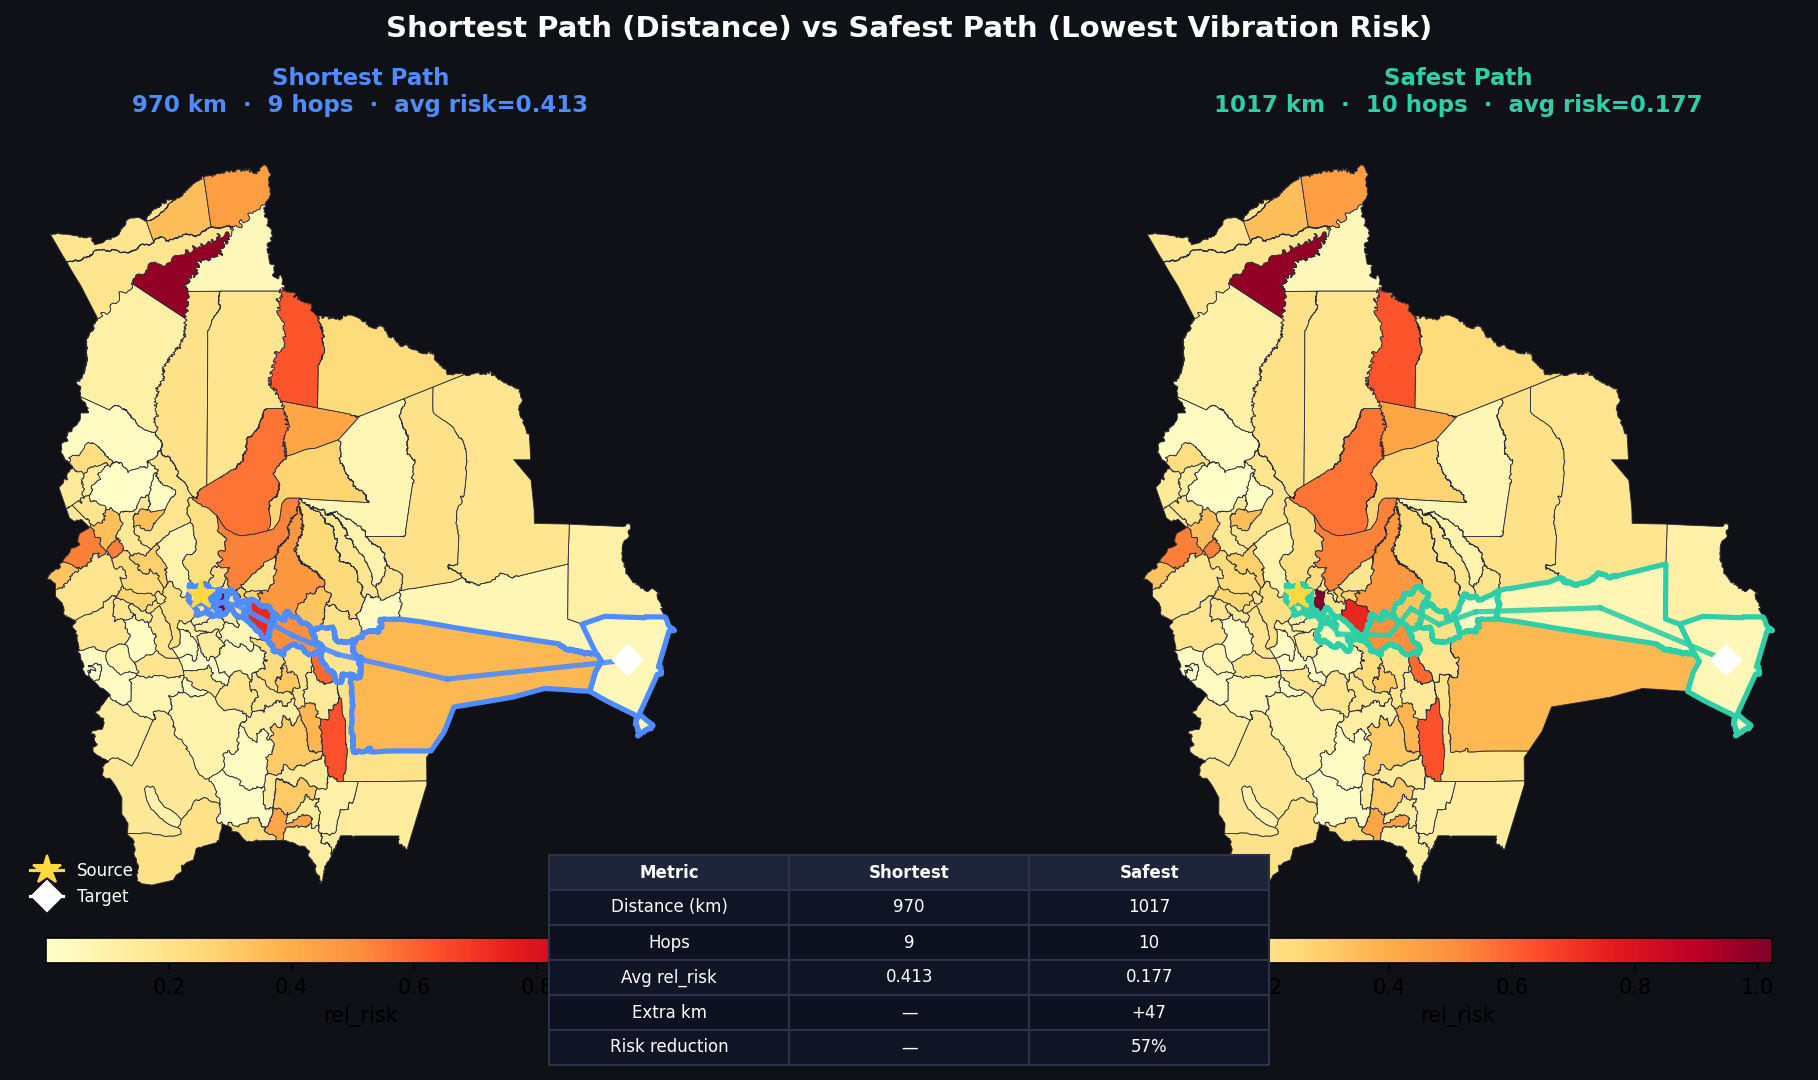

In [ ]:
from IPython.display import Image, display
display(Image("path_comparison.png"))

##Risk Surface

In [ ]:
print(f"Columns in 'joined' before subsetting: {joined.columns.tolist()}")
merged_gdf = bolivia_provinces.set_index("GID_2").join(
    joined[["GID_2", "tot_risk_road", "rel_risk", "dom_hz", "areadeg", "all_risk_road"]].set_index("GID_2")
)
merged_gdf.dropna(subset=["tot_risk_road"], inplace=True)

merged_gdf["areadeg_norm"] = merged_gdf["areadeg"] / merged_gdf["areadeg"].max()
merged_gdf["risk_surface"] = merged_gdf["rel_risk"] * (1 + merged_gdf["areadeg_norm"])

fig, axes = plt.subplots(1, 3, figsize=(20, 7), facecolor=BG)
fig.suptitle("Risk Surface: Road Risk × Climate Hazard Exposure",
             color=TC, fontsize=14, fontweight="bold")

for ax in axes:
    ax.set_facecolor(BG)
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

# Component 1: rel_risk
merged_gdf.plot(
    column="rel_risk", cmap="YlOrRd", ax=axes[0], edgecolor="#2a2a3a", linewidth=0.4,
    legend=True,
    legend_kwds={"label": "rel_risk", "orientation": "horizontal",
                 "shrink": 0.5, "pad": 0.03, "aspect": 20, "fraction": 0.04},
)
axes[0].set_title("Component 1: rel_risk\n(road damage risk per km)",
                  color=TC, fontsize=11, fontweight="bold", pad=8)

# Component 2: areadeg normalised
merged_gdf.plot(
    column="areadeg_norm", cmap="Blues", ax=axes[1], edgecolor="#2a2a3a", linewidth=0.4,
    legend=True,
    legend_kwds={"label": "areadeg (normalised)", "orientation": "horizontal",
                 "shrink": 0.5, "pad": 0.03, "aspect": 20, "fraction": 0.04},
)
axes[1].set_title("Component 2: areadeg (normalised)\n(province area fraction under hazard)",
                  color=TC, fontsize=11, fontweight="bold", pad=8)

# Combined risk surface
merged_gdf.plot(
    column="risk_surface", cmap="RdPu", ax=axes[2], edgecolor="#2a2a3a", linewidth=0.4,
    legend=True,
    legend_kwds={"label": "risk_surface = rel_risk × (1 + areadeg_norm)",
                 "orientation": "horizontal",
                 "shrink": 0.5, "pad": 0.03, "aspect": 20, "fraction": 0.04},
)
axes[2].set_title("Combined Risk Surface\nrel_risk × (1 + areadeg_norm)",
                  color=TC, fontsize=11, fontweight="bold", pad=8)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("Risk_surface.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.close()

Columns in 'joined' before subsetting: ['GID_2', 'GID_2_risk', 'NAME_1', 'NAME_2', 'idx', 'tot_risk_road', 'all_risk_road', 'rel_risk', 'dom_hz', 'areadeg']


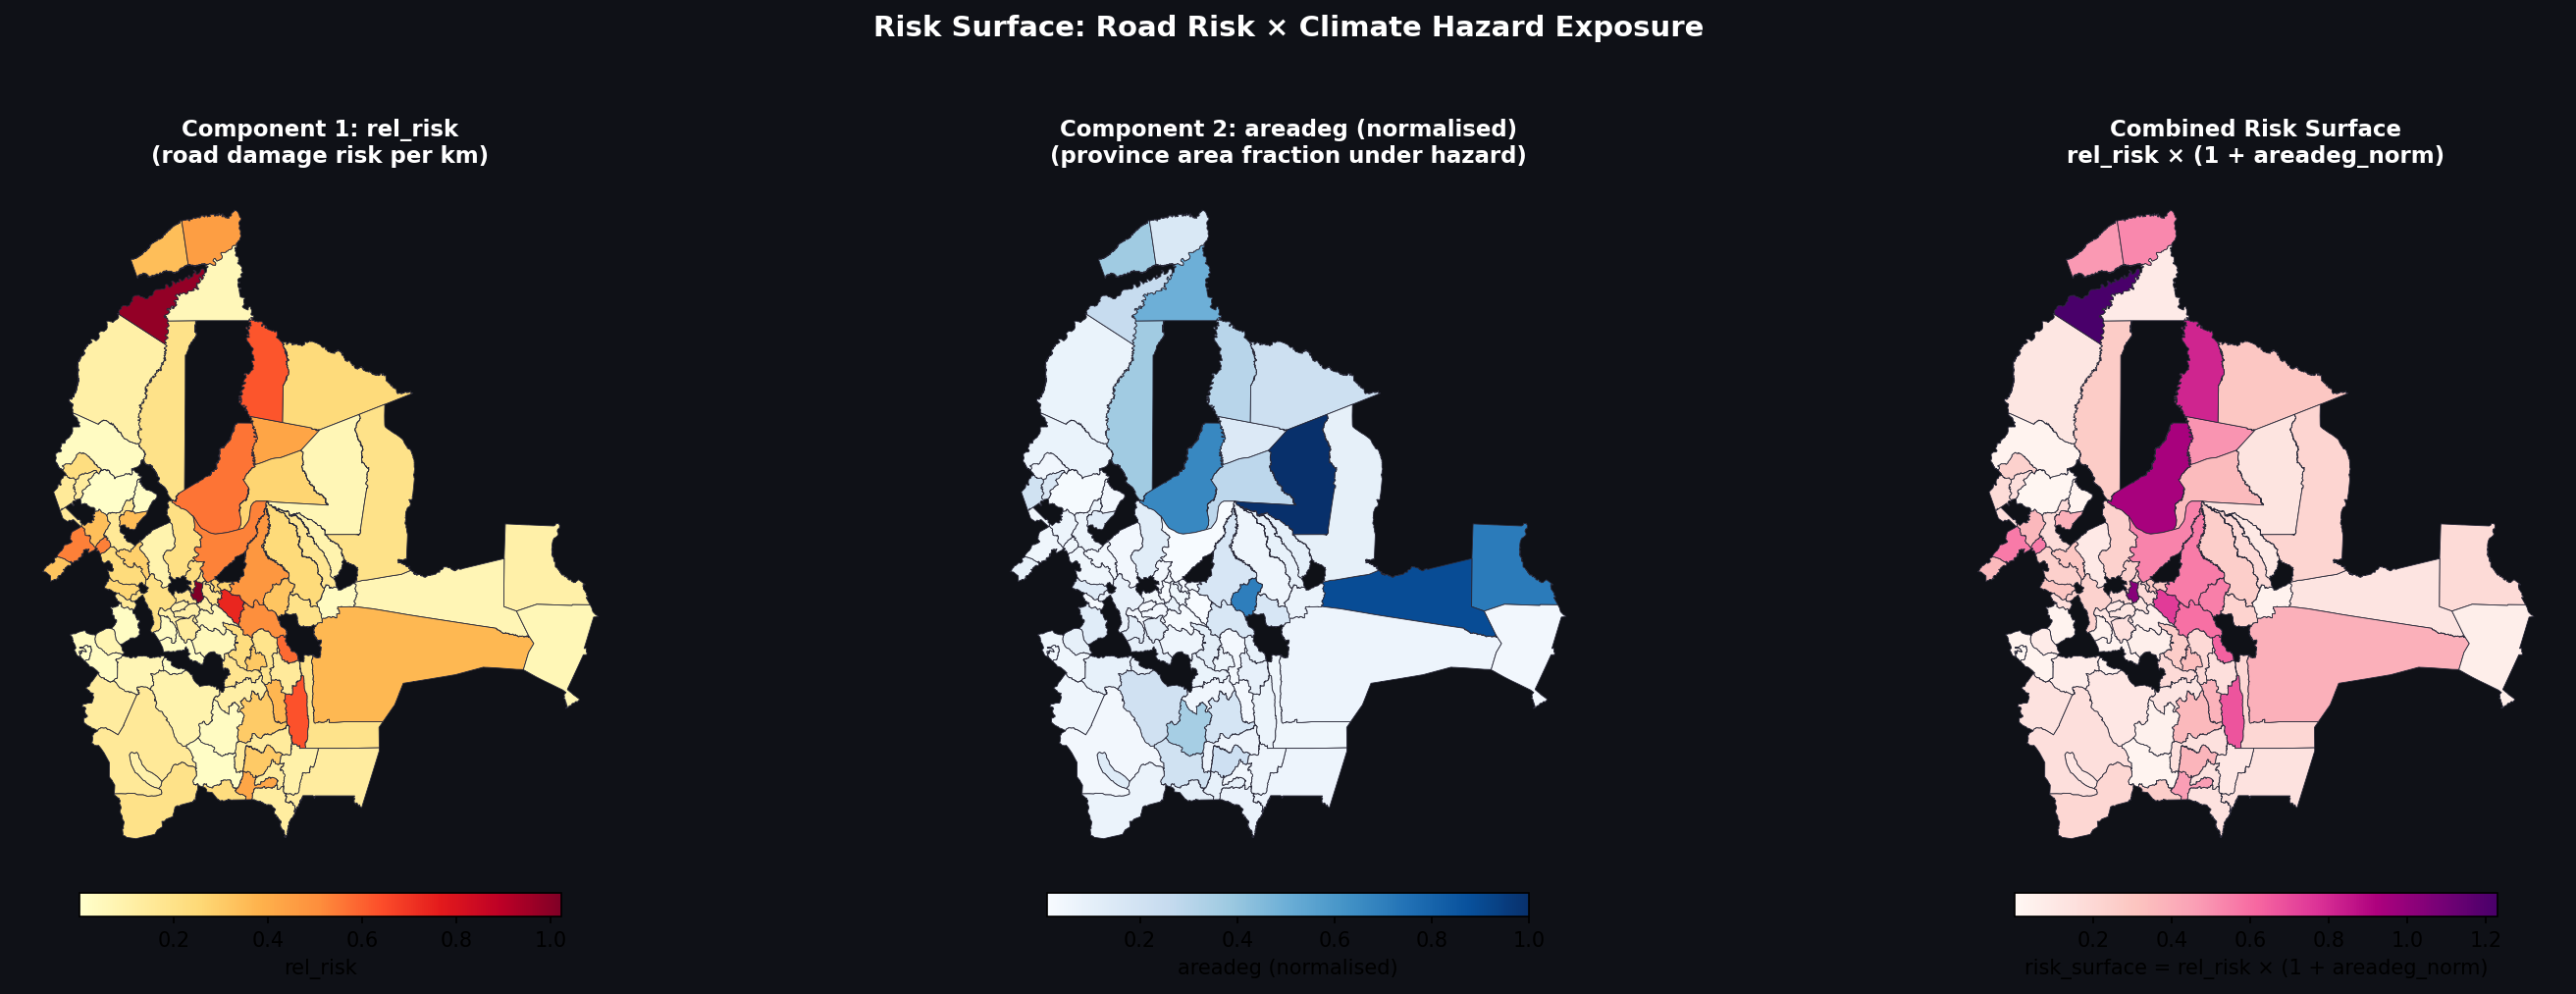

In [ ]:
from IPython.display import Image, display
display(Image("Risk_surface.png"))

##Product loss estimation

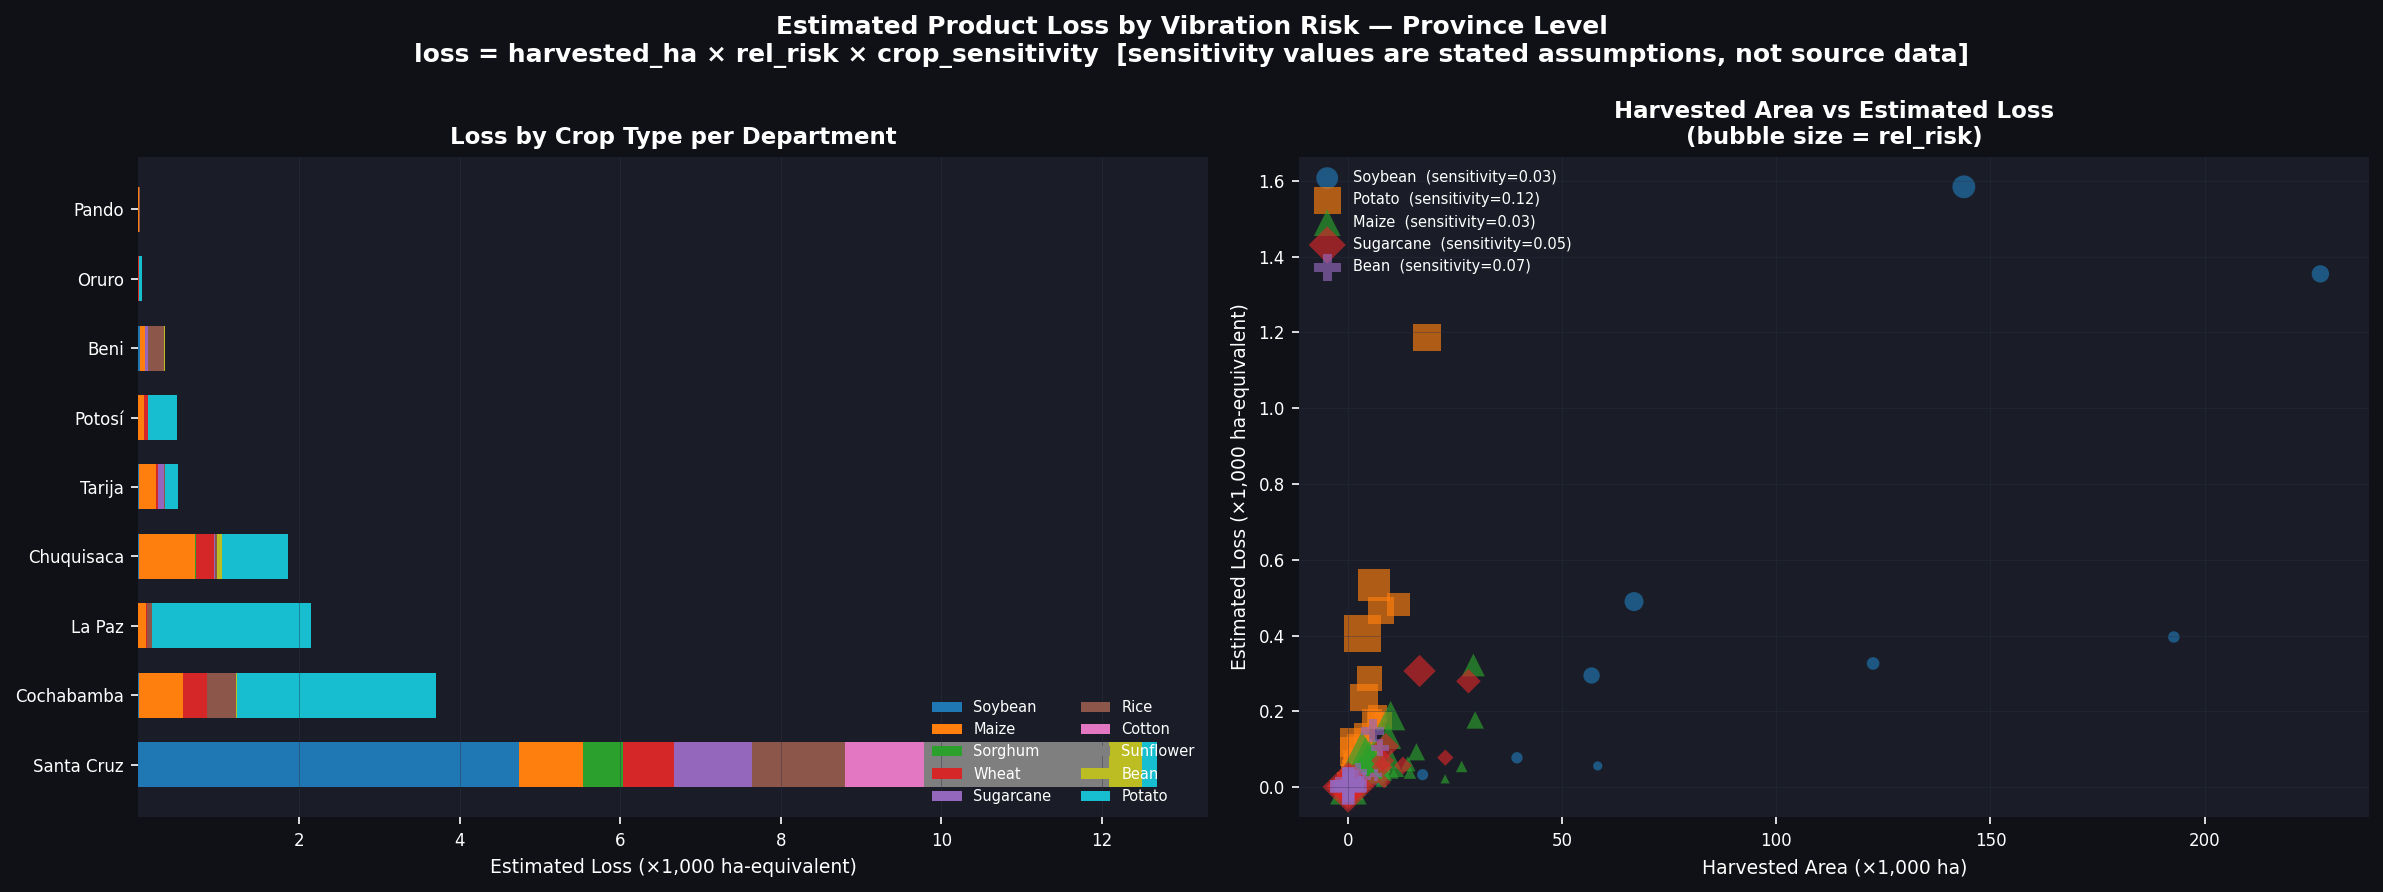

In [ ]:
from IPython.display import Image, display
display(Image("product_loss.png"))